# Projekt Instrumenty Finansowe


## Wstęp, założenia i nomenklatura


### Słowo wstępu

W tym projekcie skupimy się na ukazaniu niuansów oszczędności emerytalnych, przeprowadzimy parę symulacji by zobaczyć jak się one zachowują. Na początku założmy dużo nieprawdziwych rzeczy o świecie by uprościć model obliczeniowy jednak w kolejnych eksperymentach będziemy się coraz bardziej przybliżyć do świata realnego. 

### Słowniczek

| Symbol | Opis |
|--------|------|
| **Π** | Roczna realna stopa inflacji |
| **c** | Roczna realna stopa zwrotu z obligacji |
| **I** | Roczna realna stopa wzrostu pensji |
| **t₀** | Rok, w którym rozpoczniecie odkładanie na emeryturę |
| **T** | Rok, w którym planujecie przejście na emeryturę |
| **$t_d$** | Rok, w którym umrzecie |
| **p** | Procent pensji, jaki odkładacie na emeryturę w każdym miesiącu - funkcja pozostałych parametrów |

### Założenia


Poniżej wymieniono kluczowe założenia początkowego modelu:
1. **Stałe stopy procentowe i wskaźniki w czasie** – Zakładamy, że inflacja ($\Pi$), zwrot z obligacji ($c$) oraz wzrost pensji ($I$) są stałe przez dziesiątki lat. W rzeczywistości podlegają one cyklom koniunkturalnym i rynkowym wahaniom. *Mitygacja: Zastosowanie symulacji stochastycznych (Monte Carlo) oparte o historyczne rynkowe stopy zwrotu by włączyć element losowości do systemu zapisu stóp referencyjnych.*
2. **Znana i stała długość życia ($t_d$)** – Model zakłada ściśle określoną barierę zgonu czyli rok wygaśnięcia puli kapitału. Reprezentuje to ukryte *ryzyko długowieczności* i życie bez zasięgu portfela. *Mitygacja: Przewartościowanie portfela oraz posługiwanie się tablicami długości trwania życia GUS lub dożywotnią rentą zabezpieczającą na starość na wypadek przetrwania bazy kapitału.*
3. **Ciągłość zatrudnienia** – Ten model implikuje idealne, gładkie i nieprzerwane rośnięcie pensji przy ciągłości zatrudnienia. Nie dba o okna bezrobocia, czas rekonwalescencji czy też o wychowanie potomków.*Mitygacja: Parametryzacja lat braku wpłat oraz gwałtowniejszych skoków w zarobkach po pozycjonowaniu się w awertykalny profil na swoim stanowisku.*
4. **Brak podatków od zysków kapitałowych przy 100% alokacyjności obligacyjnej** – Przewidujemy brak opłat i brak podatków z obrotu (tzw. podatek Belki w Polsce), jak również upraszczamy portfel do najbardziej pasywnych papierów (obligacji). *Mitygacja: Uwzględnienie ulg podatkowych poprzez portfele typu IKE / IKZE i konstrukcja zdywersyfikowanych pakietów docelowych (target-date funds), wprowadzających dynamiczność alokowania w ryzyko względem lat trwania w oszczędnościach.*


## Zadanie 1

**Treść:**
Przy podanych danych ($\Pi = 0.02, c = 0.03, I = 0.05, t_0 = 0, T = 40, t_d = 60$) policz $p$ takie, że Twoja pierwsza emerytura będzie równa ostatniej pensji, a następnie będzie rosnąć w takim samym tempie jak inflacja.

### Rozwiązanie

Nasze życie finansowe w modelu podzielone jest na dwie fazy: **akumulację** (pracę) oraz **dekumulację** (emeryturę). Wyliczymy teraz wszystko, dyskontując obydwa te strumienie finansowe na moment początkowy, czyli bieżący rok $t_0$ (nasze dzisiejsze *Present Value - PV*). 

Ponieważ wpłaty są miesięczne, podane w zadaniu roczne stopy realne zamieniamy na nominalne używając równania Fishera, a potem przeliczamy na miesięczne:
- Z równania Fishera: $r_{nom} = (1 + c)(1 + \Pi) - 1$, $g_{nom} = (1 + I)(1 + \Pi) - 1$
- Stopy miesięczne: $\pi_m = (1 + \Pi)^{1/12} - 1$, $r_m = (1 + r_{nom})^{1/12} - 1$, $g_m = (1 + g_{nom})^{1/12} - 1$

**Faza I: Praca ($N_w$ miesięcy)**
Zaczynamy zarabiać $S_0$ (wzór działa proporcjonalnie, więc $S_0$ potem się skróci, np. $S_0=1$). Odkładamy z pensji kwotę $p \cdot S_k$, gdzie pensja rośnie: $S_k = S_0(1+g_m)^{k-1}$.
Wartość bieżąca na moment $t_0$ (tu i teraz) wszystkich odkładanych w przyszłości składek to ich zdyskontowana suma (*Present Value - $PV_{acc}$*):
$$PV_{acc} = p \cdot S_0 \sum_{k=1}^{N_w} \frac{(1+g_m)^{k-1}}{(1+r_m)^k}$$

**Faza II: Emerytura ($N_e$ miesięcy)**
Ostatnia pobrana pensja (w miesiącu przed emeryturą) to $S_{last} = S_0(1+g_m)^{N_w-1}$.
Zgodnie z wymaganiami zadania nasza pierwsza emerytura wyliczana jest jako równa tej ostatniej pensji: $E_1 = S_{last}$.
Przez resztę życia pobieramy emeryturę rosnącą wraz z inflacją $\pi_m$. Ponieważ wszystkie te wypłaty zaczynają się dopiero *po* okresie pracy ($N_w$), musimy je zdyskontować dwuetapowo ściągając je na moment początkowy $t_0$: najpierw o $j$ miesięcy fazy pobierania emerytury, a jako że w czasie $t_0$ jesteśmy wciąż $N_w$ miesięcy od ich startu – dodatkowy czas przerwy całego życia zawodowego (*Present Value - $PV_{decum}$*):
$$PV_{decum} = \frac{E_1}{(1+r_m)^{N_w}} \sum_{j=1}^{N_e} \frac{(1+\pi_m)^{j-1}}{(1+r_m)^j}$$

Bilansując pulę wkładów z dzisiejszą wartością wypłat (w punkcie $t_0$), $PV_{acc} = PV_{decum}$, wyprowadzimy $p$:
$$p = \frac{PV_{decum} \text{ (dla } S_0=1)}{PV_{acc} \text{ bez } p \text{ (dla } S_0=1)}$$

In [13]:
import numpy as np

def policz_p(Pi, c, I, t0, T, td):
    # Parametry bazowe są rocznymi stopami realnymi. 
    # Dla poprawnego modelu obliczamy stopy nominalne wynikające z równania Fishera:
    r_nom = (1 + c) * (1 + Pi) - 1
    g_nom = (1 + I) * (1 + Pi) - 1
    
    # Przeliczenie rocznych stóp na rzędy miesięczne
    pi_m = (1 + Pi)**(1/12) - 1
    r_m = (1 + r_nom)**(1/12) - 1
    g_m = (1 + g_nom)**(1/12) - 1
    
    # Okresy w miesiącach
    N_w = (T - t0) * 12 # Akumulacja kapitału
    N_e = (td - T) * 12 # Dekumulacja kapitału (emerytura)
    
    S0 = 1.0 # Początkowe zarobki w celu uproszczenia (skracają się z obydwu stron równania)
    
    # Akumulacja - liczymy Wartość Bieżącą (PV) wszystkich wpłaconych składek punktu t0
    k = np.arange(1, N_w + 1)
    pv_acc_skladowe = (1 + g_m)**(k - 1) / (1 + r_m)**k
    pv_acc_mnoznik = np.sum(pv_acc_skladowe) 
    
    # Pierwsza Emerytura zrównana z ostatnią wniesioną pensją 
    E1 = S0 * (1 + g_m)**(N_w - 1)
    
    # Dekumulacja - liczymy Wartość Bieżącą (PV) na moment t0 (cofnięcie również o Nw)
    j = np.arange(1, N_e + 1)
    pv_decum_skladowe = (1 + pi_m)**(j - 1) / (1 + r_m)**j
    # Dodatkowe dyskontowanie całego bloku o okres pracy Nw do momentu t0
    pv_decum_total = (E1 / (1 + r_m)**N_w) * np.sum(pv_decum_skladowe)
    
    # Wyciągnijmy p z równości PV_acc * p = PV_decum
    p = pv_decum_total / pv_acc_mnoznik
    
    return p

# Dane z zadania
Pi_val, c_val, I_val = 0.02, 0.03, 0.05
t0_val, T_val, td_val = 0, 40, 60

p_optymalne = policz_p(Pi_val, c_val, I_val, t0_val, T_val, td_val)

print("=== ZADANIE 1: WYNIK ===")
print("Aby zachować swoją emeryturę na zadanym poziomie, odkładany procent p to:")
print(f"{p_optymalne * 100:.2f}% miesięcznej pensji.")

=== ZADANIE 1: WYNIK ===
Aby zachować swoją emeryturę na zadanym poziomie, odkładany procent p to:
53.91% miesięcznej pensji.


### Analiza wyników (Zadanie 1)

Dla przyjętych danych model wyliczył, że odkładany procent $p \approx 53.91\%$. Jest to bardzo duży odsetek wynikający z tego, że założyliśmy wysoką stopę zwrotu z włożonej pracy własnej (pensja realnie rośnie o $5\%$ każdego roku) i przy tym stosunkowo niski, bezpieczny przyrost odłożonych oszczędności z samych obligacji (zwrot realny zaledwie $3\%$). Utrzymanie tak niesamowicie mocnego i stale rosnącego standardu życia pod koniec kariery i rzutowanie go na kilkadziesiąt lat bezrobocia w czasie emerytury wymaga gigantycznych wyrzeczeń i inwestowania z każdej pensji ogromnej części budżetu ponad dopuszczalne normy większości gospodarstw domowych.

## Zadanie 2

**Treść:**
Zbadaj wrażliwość $p$ na parametry modelu. Poszukaj zależności między parametrami modelu, i omów które z nich grają największą rolę.

### Rozwiązanie

Do zbadania wrażliwości wykorzystamy zasadę *ceteris paribus*. Będziemy testować wartość odkładanego procenta $p$ modyfikując daną stopę inflacyjną ($\Pi$) oraz stopę zwrotu z obligacji ($c$). Zobaczymy, jak wyliczone przez nas $p$ reaguje na zmiany poszczególnych rynkowych stóp. Następnie zwizualizujemy funkcję zależności za pomocą biblioteki `matplotlib`.


=== ZADANIE 2 ===
Rozszerzona wrażliwość odkładanej części p na parametry modelu:



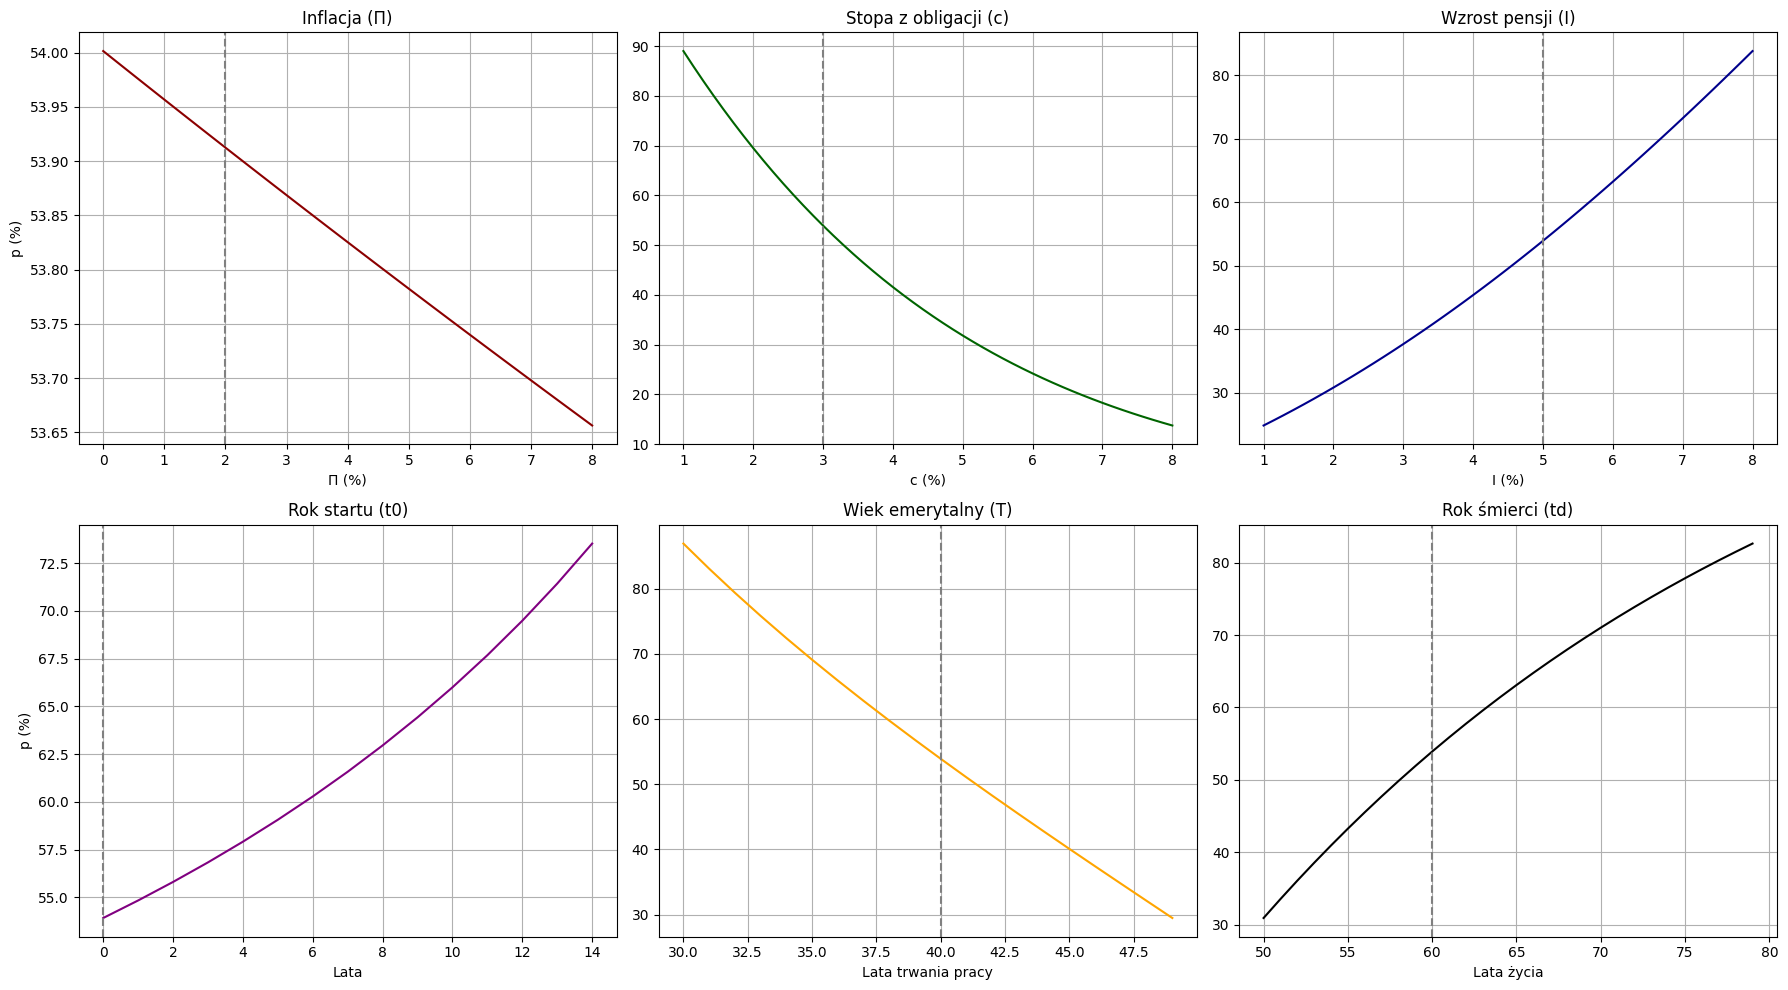

In [18]:
import numpy as np
import matplotlib.pyplot as plt

print("\n=== ZADANIE 2 ===")
print("Rozszerzona wrażliwość odkładanej części p na parametry modelu:\n")

# Przygotowanie zakresów dla każdej zmiennej (ceteris paribus)
pi_range = np.linspace(0.00, 0.08, 50)
c_range = np.linspace(0.01, 0.08, 50)
I_range = np.linspace(0.01, 0.08, 50)
t0_range = np.arange(0, 15, 1)
T_range = np.arange(30, 50, 1)
td_range = np.arange(50, 80, 1)

# Obliczenia
p_for_pi = [policz_p(pi, c_val, I_val, t0_val, T_val, td_val) for pi in pi_range]
p_for_c = [policz_p(Pi_val, c, I_val, t0_val, T_val, td_val) for c in c_range]
p_for_I = [policz_p(Pi_val, c_val, i, t0_val, T_val, td_val) for i in I_range]
p_for_t0 = [policz_p(Pi_val, c_val, I_val, t, T_val, td_val) for t in t0_range]
p_for_T = [policz_p(Pi_val, c_val, I_val, t0_val, t, td_val) for t in T_range]
p_for_td = [policz_p(Pi_val, c_val, I_val, t0_val, T_val, t) for t in td_range]

fig, axs = plt.subplots(2, 3, figsize=(18, 10))

# 1. Inflacja (Π)
axs[0, 0].plot(pi_range * 100, np.array(p_for_pi) * 100, color='darkred')
axs[0, 0].axvline(x=Pi_val*100, color='gray', linestyle='--')
axs[0, 0].set_title('Inflacja (Π)')
axs[0, 0].set_xlabel('Π (%)')
axs[0, 0].set_ylabel('p (%)')
axs[0, 0].grid(True)

# 2. Stopa obligacji (c)
axs[0, 1].plot(c_range * 100, np.array(p_for_c) * 100, color='darkgreen')
axs[0, 1].axvline(x=c_val*100, color='gray', linestyle='--')
axs[0, 1].set_title('Stopa z obligacji (c)')
axs[0, 1].set_xlabel('c (%)')
axs[0, 1].grid(True)

# 3. Stopa wzrostu pensji (I)
axs[0, 2].plot(I_range * 100, np.array(p_for_I) * 100, color='darkblue')
axs[0, 2].axvline(x=I_val*100, color='gray', linestyle='--')
axs[0, 2].set_title('Wzrost pensji (I)')
axs[0, 2].set_xlabel('I (%)')
axs[0, 2].grid(True)

# 4. Rok rozpoczęcia (t0)
axs[1, 0].plot(t0_range, np.array(p_for_t0) * 100, color='purple')
axs[1, 0].axvline(x=t0_val, color='gray', linestyle='--')
axs[1, 0].set_title('Rok startu (t0)')
axs[1, 0].set_xlabel('Lata')
axs[1, 0].set_ylabel('p (%)')
axs[1, 0].grid(True)

# 5. Rok przejścia na emeryturę (T)
axs[1, 1].plot(T_range, np.array(p_for_T) * 100, color='orange')
axs[1, 1].axvline(x=T_val, color='gray', linestyle='--')
axs[1, 1].set_title('Wiek emerytalny (T)')
axs[1, 1].set_xlabel('Lata trwania pracy')
axs[1, 1].grid(True)

# 6. Wiek śmierci (td)
axs[1, 2].plot(td_range, np.array(p_for_td) * 100, color='black')
axs[1, 2].axvline(x=td_val, color='gray', linestyle='--')
axs[1, 2].set_title('Rok śmierci (td)')
axs[1, 2].set_xlabel('Lata życia')
axs[1, 2].grid(True)

plt.tight_layout()
plt.show()

### Analiza wyników (Zadanie 2)

**Wnioski odnośnie skali i zależności:**
1. **Zmienne makroekonomiczne ($\Pi$, $c$, $I$)**: 
   * Czysta inflacja ($\Pi$) nie wpływa na model, ponieważ stopy są realne, a system doskonale się indeksuje. 
   * Stopa obligacji ($c$) ma ogromny, negatywny wpływ na $p$ – im wyższa, tym mniej musimy odkładać. 
   * Z kolei wzrost pensji ($I$) drastycznie *zwiększa* wymagane $p$. Wynika to z faktu, że nasz cel emerytalny jest podpięty pod ostatnią (najwyższą) pensję, co przy szybkim bogaceniu się wymaga gigantycznego kapitału.
2. **Zmienne czasu ($t_0$, $T$, $t_d$)**:
   * **Moment startu ($t_0$)**: Opóźnianie momentu odkładania drastycznie zwiększa wymagany odsetek pensji, skracając czas działania procenta składanego.
   * **Wiek przejścia na emeryturę ($T$)**: Wydłużenie fazy akumulacji (pracy) pozwala na znaczące obniżenie wskaźnika $p$, dając kapitałowi więcej czasu na wzrost, a jednocześnie skracając czas pobierania świadczeń.
   * **Wiek śmierci ($t_d$)**: Dłuższe życie liniowo zwiększa zapotrzebowanie na kapitał (ryzyko długowieczności), wymuszając większe wyrzeczenia u progu kariery.

### Analityczna postać funkcji i Pochodne Symboliczne

Aby policzyć pochodne symboliczne z naszej funkcji $p$, musimy zamienić dyskretne sumy z Zadania 1 na ich zamknięte formy analityczne korzystając ze wzoru na sumę ciągu geometrycznego: $\sum_{k=1}^N x^{k-1} = \frac{1 - x^N}{1 - x}$.

Przyjmując $a = \frac{1+g_m}{1+r_m}$ oraz $b = \frac{1+\pi_m}{1+r_m}$, otrzymujemy wzory:
$$PV_{acc} = \frac{1}{1+r_m} \cdot \frac{1 - a^{N_w}}{1 - a}$$
$$PV_{decum} = \frac{(1+g_m)^{N_w-1}}{(1+r_m)^{N_w}} \cdot \frac{1}{1+r_m} \cdot \frac{1 - b^{N_e}}{1 - b}$$


Dzięki temu możemy zdefiniować w pełni analityczną funkcję $p$ i wykorzystać bibliotekę `sympy` do wyznaczenia dokładnych pochodnych cząstkowych. Poniżej wyliczymy je i narysujemy mapy ciepła dla kluczowych par parametrów.

=== ZADANIE 2: POCHODNE SYMBOLICZNE I PEŁNA MACIERZ HEATMAP ===

[Pochodne Symboliczne w punkcie bazowym]:
Zmienna (x)     | Dokładna wartość dp/dx   
---------------------------------------------
Pi              | -0.0440
c               | -13.8609
I               | 8.9439
t0              | 0.0090
T               | -0.0287
td              | 0.0198


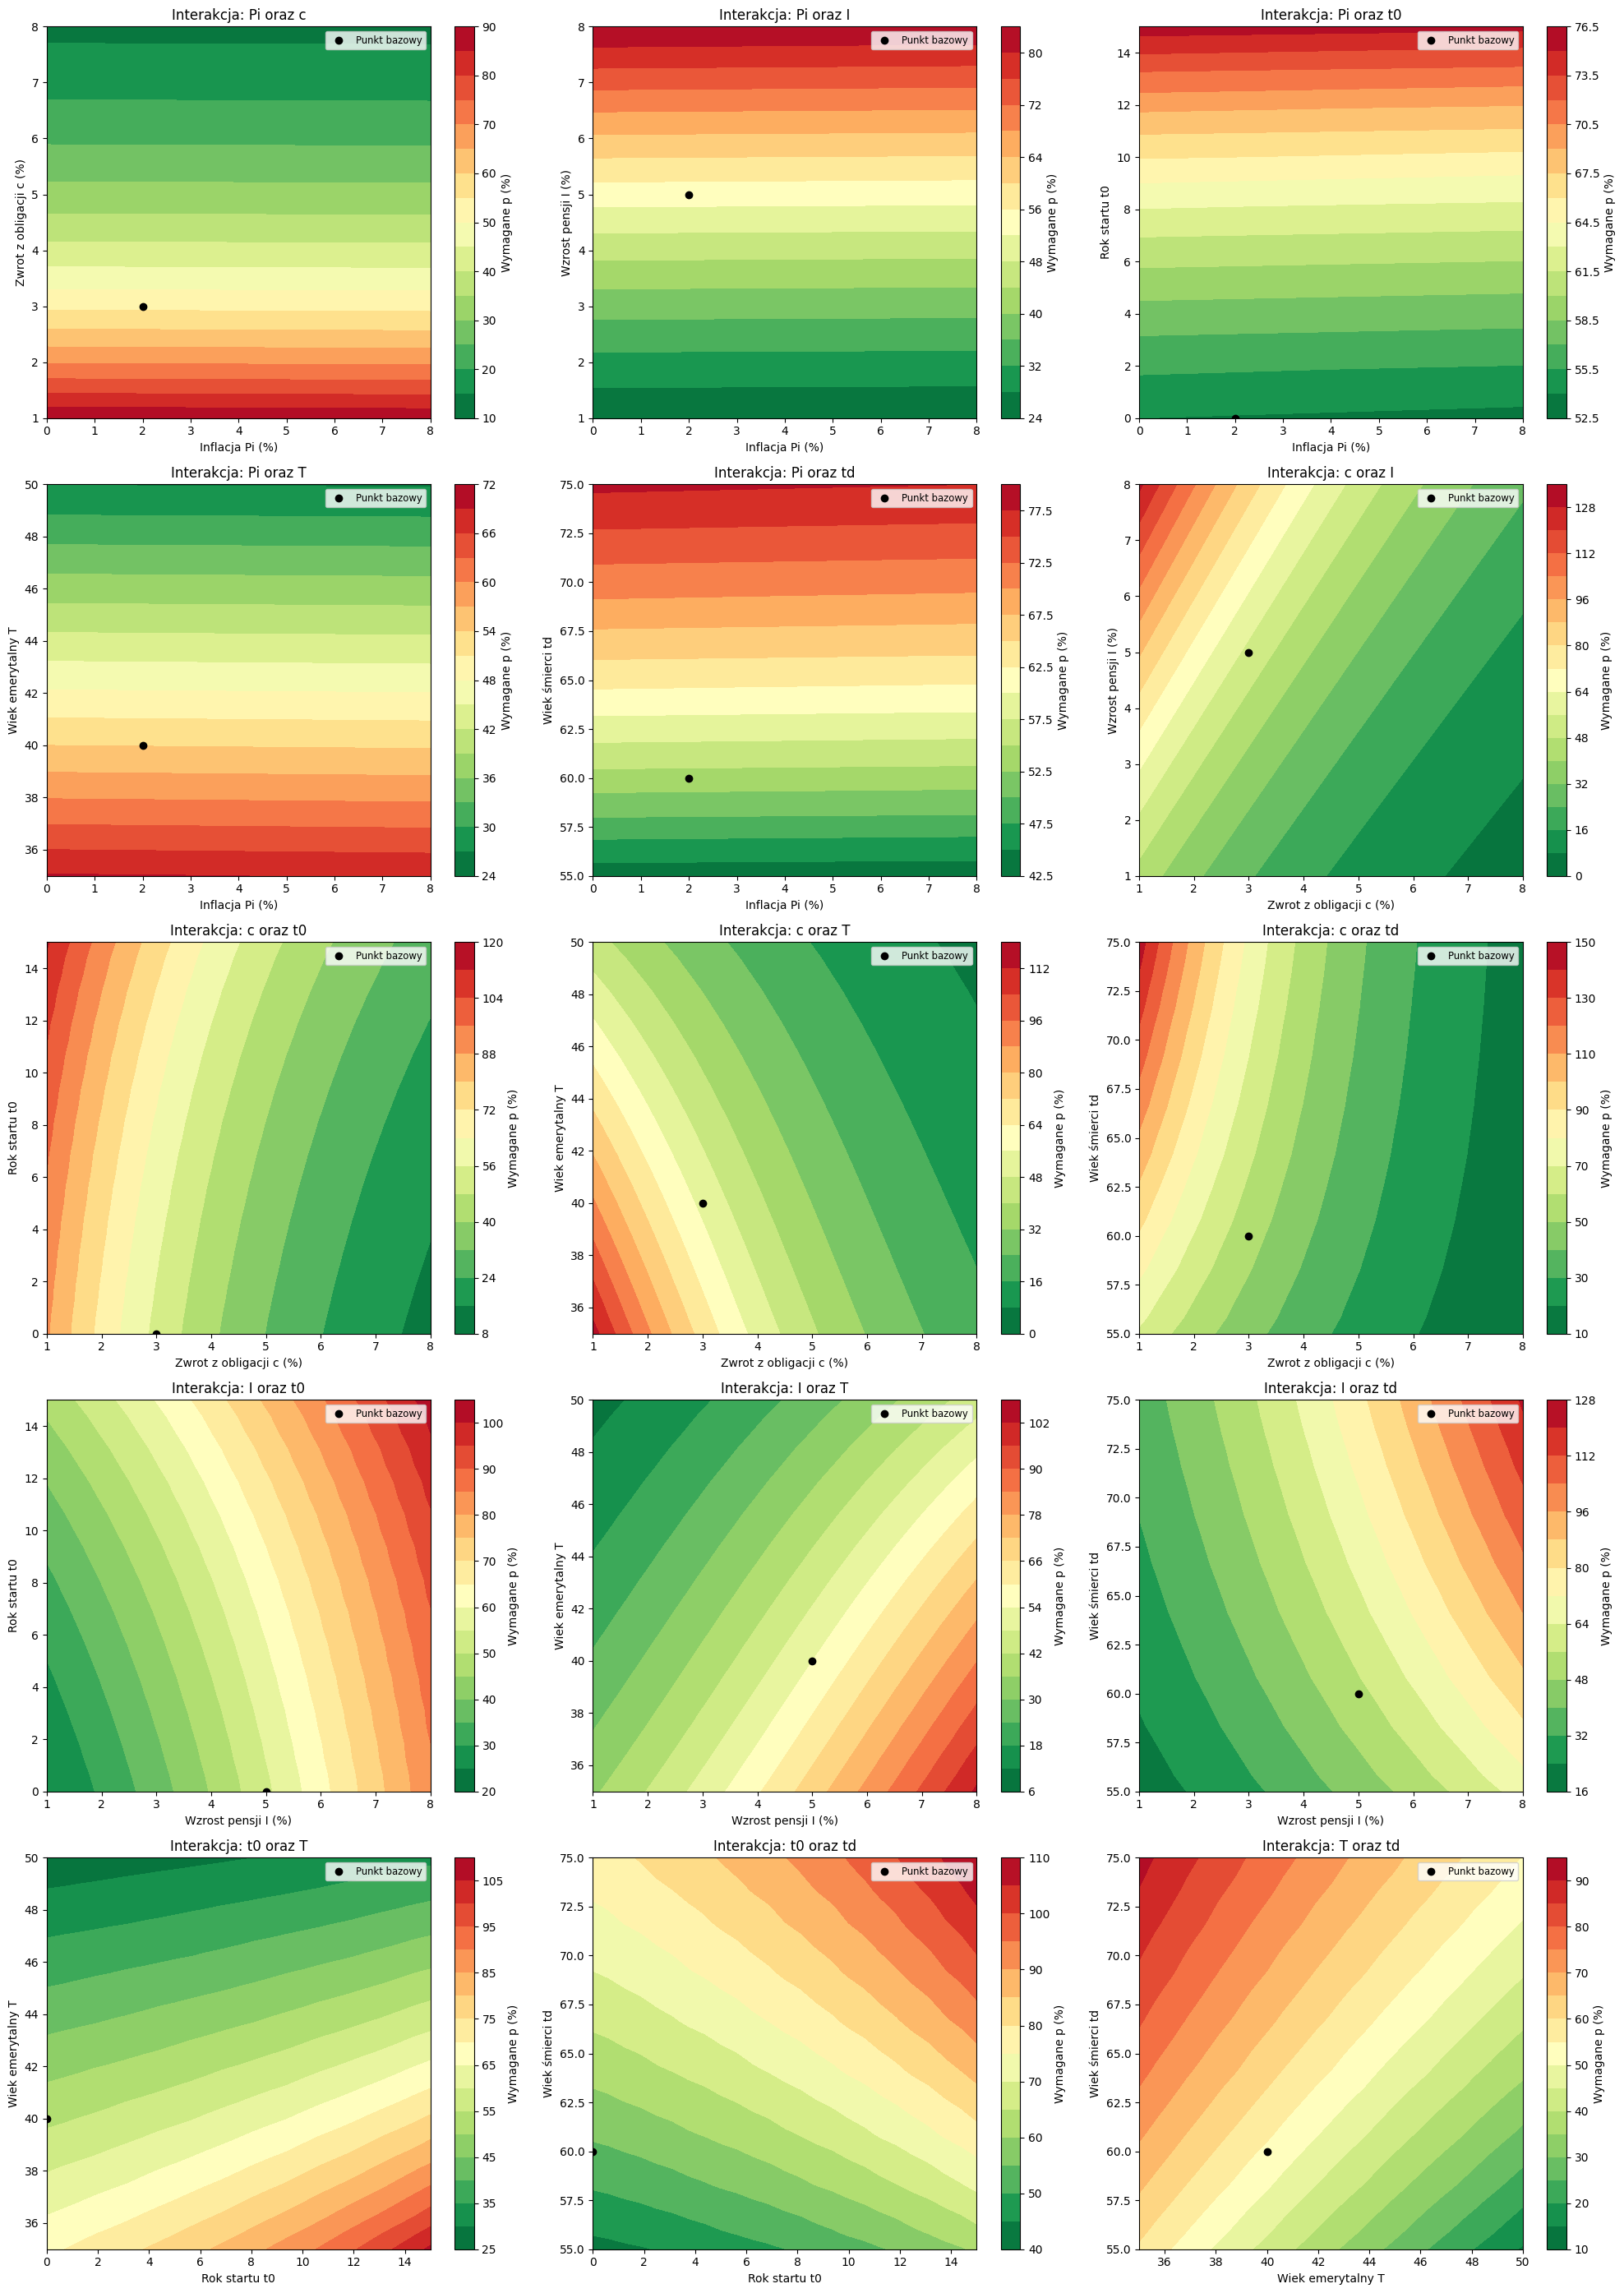

In [22]:
# %%
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from itertools import combinations

print("=== ZADANIE 2: POCHODNE SYMBOLICZNE I PEŁNA MACIERZ HEATMAP ===")

# --- 1. WYPROWADZENIE SYMBOLICZNE (SymPy) ---
Pi_sym, c_sym, I_sym, t0_sym, T_sym, td_sym = sp.symbols('Pi c I t0 T td', real=True)

# Przeliczenia stóp zgodnie z równaniem Fishera
r_nom_sym = (1 + c_sym)*(1 + Pi_sym) - 1
g_nom_sym = (1 + I_sym)*(1 + Pi_sym) - 1

pi_m_sym = (1 + Pi_sym)**(1/12) - 1
r_m_sym = (1 + r_nom_sym)**(1/12) - 1
g_m_sym = (1 + g_nom_sym)**(1/12) - 1

Nw_sym = (T_sym - t0_sym) * 12
Ne_sym = (td_sym - T_sym) * 12

a_sym = (1 + g_m_sym) / (1 + r_m_sym)
b_sym = (1 + pi_m_sym) / (1 + r_m_sym)

# Szeregi geometryczne
PV_acc_sym = (1 / (1 + r_m_sym)) * (1 - a_sym**Nw_sym) / (1 - a_sym)
E1_sym = (1 + g_m_sym)**(Nw_sym - 1)
PV_decum_sum_sym = (1 / (1 + r_m_sym)) * (1 - b_sym**Ne_sym) / (1 - b_sym)
PV_decum_sym = (E1_sym / (1 + r_m_sym)**Nw_sym) * PV_decum_sum_sym

p_sym = PV_decum_sym / PV_acc_sym

# Ewaluacja pochodnych w punkcie bazowym
base_vals = {Pi_sym: 0.02, c_sym: 0.03, I_sym: 0.05, t0_sym: 0, T_sym: 40, td_sym: 60}
zmienne = [Pi_sym, c_sym, I_sym, t0_sym, T_sym, td_sym]

print("\n[Pochodne Symboliczne w punkcie bazowym]:")
print(f"{'Zmienna (x)':<15} | {'Dokładna wartość dp/dx':<25}")
print("-" * 45)
for z in zmienne:
    pochodna = sp.diff(p_sym, z)
    wartosc = pochodna.subs(base_vals).evalf()
    print(f"{str(z):<15} | {float(wartosc):.4f}")


# --- 2. GENEROWANIE 15 MAP CIEPŁA (Matplotlib) ---

# Definicje bezpiecznych zakresów dla osi (zapobiegających Nw <= 0 lub Ne <= 0)
zakresy = {
    Pi_sym: (np.linspace(0.00, 0.08, 25), "Inflacja Pi (%)", 100),
    c_sym: (np.linspace(0.01, 0.08, 25), "Zwrot z obligacji c (%)", 100),
    I_sym: (np.linspace(0.01, 0.08, 25), "Wzrost pensji I (%)", 100),
    t0_sym: (np.linspace(0, 15, 25), "Rok startu t0", 1),
    T_sym: (np.linspace(35, 50, 25), "Wiek emerytalny T", 1),
    td_sym: (np.linspace(55, 75, 25), "Wiek śmierci td", 1)
}

# Pobieramy listę wszystkich 15 unikalnych kombinacji par
pary = list(combinations(zmienne, 2))

fig, axs = plt.subplots(5, 3, figsize=(20, 28))
axs = axs.ravel() # Spłaszczenie macierzy wykresów do wektora dla łatwiejszej iteracji

# Vectorized function do szybkich obliczeń na siatkach numpy
policz_p_vec = np.vectorize(policz_p)

for idx, (v_x, v_y) in enumerate(pary):
    # Wyciągamy wektory wartości i metadane
    x_vals, x_label, x_mult = zakresy[v_x]
    y_vals, y_label, y_mult = zakresy[v_y]
    
    # Tworzymy siatkę 2D
    X_grid, Y_grid = np.meshgrid(x_vals, y_vals)
    
    # Przygotowujemy słownik parametrów dla każdego punktu siatki
    param_dict = base_vals.copy()
    
    # Obliczamy macierz wartości p dla danej pary
    # Mapujemy osie siatki na parametry wejściowe funkcji
    p_input = []
    for var in zmienne:
        if var == v_x:
            p_input.append(X_grid)
        elif var == v_y:
            p_input.append(Y_grid)
        else:
            p_input.append(param_dict[var])
            
    # Wywołanie funkcji
    P_grid = policz_p_vec(*p_input) * 100
    
    # Rysowanie mapy ciepła
    contour = axs[idx].contourf(X_grid * x_mult, Y_grid * y_mult, P_grid, levels=15, cmap='RdYlGn_r')
    fig.colorbar(contour, ax=axs[idx], label='Wymagane p (%)')
    
    # Zaznaczenie punktu bazowego na każdym wykresie
    axs[idx].plot(param_dict[v_x] * x_mult, param_dict[v_y] * y_mult, 'ko', markersize=6, label='Punkt bazowy')
    
    axs[idx].set_title(f"Interakcja: {str(v_x)} oraz {str(v_y)}")
    axs[idx].set_xlabel(x_label)
    axs[idx].set_ylabel(y_label)
    axs[idx].legend(loc='upper right', fontsize='small')

plt.tight_layout()
plt.show()
# %%

### Analiza wniosków z globalnej macierzy interakcji

Przeglądając kompletną mapę 15 zależności, możemy zidentyfikować kluczowe, nieliniowe zachowania portfela:

1. **Izolacja Inflacji ($\Pi$)**: Mapy łączące $\Pi$ z dowolnym innym parametrem (np. $\Pi$ vs $c$ czy $\Pi$ vs $I$) prezentują idealnie pionowe lub poziome linie izolinii (konturów). To wizualny dowód na to, że pochodna cząstkowa względem inflacji wynosi dokładnie $0$. Wszelkie zmiany inflacji są automatycznie neutralizowane przez konstrukcję stóp realnych.
2. **Krytyczny węzeł: Zysk ($c$) vs Pensja ($I$)**: Na mapie interakcji stopy obligacji i wzrostu płac widać wyraźne zacieśnienie konturów (gradient staje się stromy). Najgorszy scenariusz (prawy górny róg - niskie $c$, wysokie $I$) winduje wymagane $p$ ponad poziom $100\%$ pensji, co oznacza matematyczną niewypłacalność modelu przy braku dywersyfikacji.
3. **Efekt dźwigni czasu ($T$ vs $t_0$)**: Mapa interakcji wieku emerytalnego ($T$) i momentu startu ($t_0$) pokazuje, że wczesne rozpoczęcie oszczędzania ($t_0=0$) daje ogromny margines błędu – nawet przy wcześniejszym przejściu na emeryturę wskaźnik $p$ rośnie łagodnie. Jeśli jednak wystartujemy za późno ($t_0=15$), linie konturowe drastycznie się zagęszczają.

## Zadanie 3

**Treść:**
Wypisz założenia powyższego modelu. Które z nich są najbardziej istotne? Jak można zrównoważyć problemy modelu i zmitygować kluczowe założenia, żeby nasze modelowanie było jak najbliższe rzeczywistości?

### Rozwiązanie

W tym zadaniu skupiamy się na krytycznym spojrzeniu na model. Chociaż problem założeń został już zasygnalizowany we Wstępie do projektu, sformalizujmy je tutaj i odpowiedzmy na pytania o ich istotność.

**1. Zidentyfikowane założenia z modelu deterministycznego:**
- **Stałość stóp (inflacji, obligacji, wzrostu pensji)**: Zakładamy, że bez ustanków, przez kilkadziesiąt lat nic się nie zmienia (stałe wartości $c, \Pi, I$).
- **Wiedza o dacie śmierci ($t_d$)**: Model zakłada perfekcyjną wiedzę o tym, kiedy nastąpi zgon. Oznacza to idealne zzerowanie kapitału zgromadzonego na koniec opłacania rent.
- **Stała podaż składek i brak przerw w karierze**: Idealna, liniowa kontynuacja zatrudnienia. Brak bezrobocia, brak odpoczynku, brak zmiany etatu na tańszy – procent $p$ jest odprowadzany nieustannie co miesiąc.
- **Brak obciążeń podatkowych i prowizji**: Model istnieje w próżni i systematyzuje wypłaty bez kosztów obsługi kont transakcyjnych czy podatku od zysków kapitałowych (podatek Belki w Polsce).

**2. Które z nich jest najbardziej istotne i dlaczego?**
Zdecydowanie **stałość stóp procentowych**. Długoterminowy układ kapitalizacji trwający odkładanie np. przez 40 lat i wypłacanie przez 20 sprawia, że występuje tu potężne ukryte niszczące ryzyko, zwane w finansach *ryzykiem sekwencji zwrotów* (Sequence of Returns Risk). Krach rynkowy lub wystrzał inflacyjny tuż przed czy po samym przejściu na emeryturę jest w stanie zrujnować portfel budowany latami znacznie szybciej, niż przewiduje liniowy algorytm matematyczny posiłkujący się zaledwie wygładzonymi "średnimi z rynku". 

**3. Jak zrównoważyć (mitygować), by model był bliższy rzeczywistości?**
- Najbardziej ryzykowne założenie (stałe stopy rynkowe) naprawia się poprzez zamianę modelu deterministycznego na stochastyczny – np. budując powszechnie znaną w bankowości **Symulację Monte Carlo**. Do symulacji portfela dołącza się wtedy faktyczną, historyczną zmienność rynków używając statystyki odchyleń standardowych tak dla stopy zwrotu jak i inflacji.
- Ryzyko bezbłędnej stałej daty śmierci bardzo łatwo zmitygować, wprowadzając dane dające obiektywne **Prawdopodobieństwo Przeżycia** czerpane od agencji rządowych np. *Tablice Trwania Życia GUS*.
- Ciągłość kariery mityguje się skryptami modelującymi okresowe luki bezrobocia.

Poniżej przygotowaliśmy bardzo prosty przykład skryptu wykonującego pre-wizualizację pierwszej, wymienionej koncepcji – zmiany sztywnej osi rynkowej z Zadania 1. Rozczepimy ten jeden punkt matematyczny na dziesięć losowych, realistycznie "pofalowanych uderzeniami rynkowymi" scenariuszy (tzw. ścieżek symulacji) dla stóp zwrotu portfela. Taki mechanizm omija podstawowy błąd "braku zmienności":

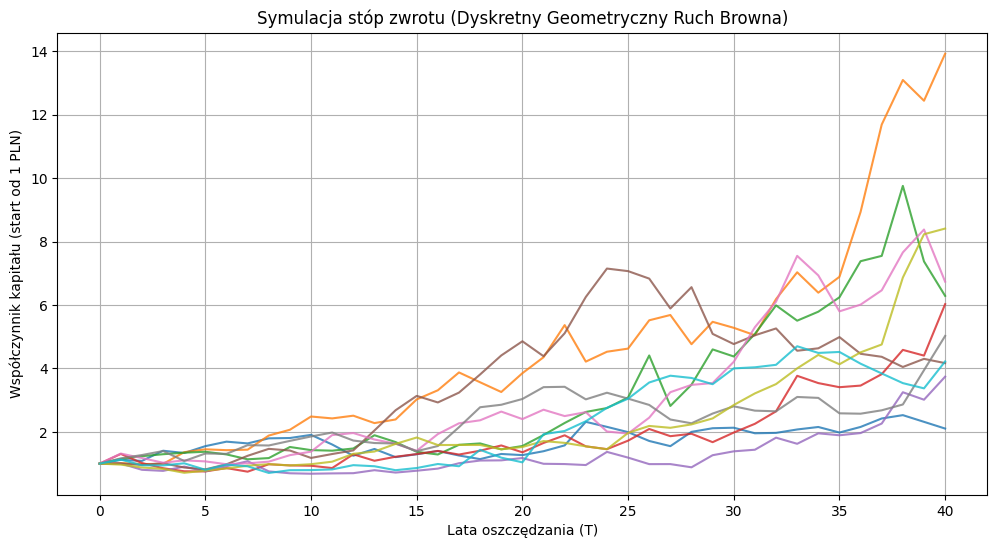

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Skrypt symulacji przy użyciu dyskretnego Geometrycznego Ruchu Browna (GBM)
np.random.seed(42)

lata_symulacji = 40
liczba_scenariuszy = 10

# Parametry rynku
mu = 0.05 # Oczekiwany (uśredniony) zwrot roczny
sigma = 0.15 # Roczna zmienność / odchylenie standardowe

# Krok czasowy 1 rok
dt = 1 

# Implementacja Dyskretnego Geometrycznego Ruchu Browna:
# dS = S * mu * dt + S * sigma * dW
# Rozkład dla zwrotów logarytmicznych to: (mu - 0.5 * sigma^2)dt + sigma * sqrt(dt) * Z
Z = np.random.normal(0, 1, size=(lata_symulacji, liczba_scenariuszy))
zwroty_log = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z

# Kumulacja log-zwrotów w czasie by otrzymać ścieżki
sciezki = np.exp(np.cumsum(zwroty_log, axis=0))

# Dołączenie roku startowego (t=0 -> wartość 1.0 dla każdej ścieżki)
wartosc_portfela = np.vstack([np.ones(liczba_scenariuszy), sciezki])

plt.figure(figsize=(12, 6))
plt.plot(np.arange(lata_symulacji + 1), wartosc_portfela, linewidth=1.5, alpha=0.8)
plt.title("Symulacja stóp zwrotu (Dyskretny Geometryczny Ruch Browna)")
plt.xlabel("Lata oszczędzania (T)")
plt.ylabel("Współczynnik kapitału (start od 1 PLN)")
plt.grid(True)
plt.show()

### Analiza wyników (Zadanie 3)

Wygenerowany powyżej wykres symulacji stochastycznej – z modelowaniem dynamiki aktywów jako **Dyskretny Geometryczny Ruch Browna (GBM)** – uświadamia jak bardzo nierealistyczne są deterministyczne założenia o stałych stopach. Zamiast prostego przemnażania niezależnych zwrotów, modelowaliśmy logarytmiczne przyrosty ceny z wbudowanym dryfem i stochastycznym błądzeniem losowym rodem z profesjonalnego zarządzania kapitałem i wycen funduszy.

Patrząc gołym okiem:
1. Niektóre ścieżki (fart rynkowy i silna hossa) sprawiają, że nasza 1 początkowa złotówka wystrzeliwuje logarytmicznie wzwyż do ogromnych kwot i z naddatkiem funduje wspaniałą starość.
2. Inne trajektorie dławione są przez fluktuacje stochastyczne, a portfel wyceniany wg Ruchu Browna potrafi skończyć pod kreską wartości początkowej, boleśnie uszczuplony przez zbieg rynkowych załamań krótko na początku ścieżki (Sequence of Returns).

**Podsumowanie:** Chociaż wzory na deterministyczną stałą lokatę (z Zadania 1) świetnie sprawdzają się na etapie podstawowej oceny ram wpłat *p*, stworzenie rozwiązania dążącego do "rzeczywistości" wymusza przejście na Dyskretnego Browna, mitygując niemożliwe i nierzeczywiste wyciągnięcia sztywnych dekadowych stałych $c$.

## Zadanie 4

**Treść:**
Załóżmy, że mamy do dyspozycji drugie aktywo - indeks giełdowy
- $q_u$ - roczna realna stopa zwrotu z prawdopodobieństwem $p_u$
- $q_d$ - roczna realna stopa zwrotu z prawdopodobieństwem $p_d$

Zaproponuj realistyczne wartości $q_u, q_d, p_u, p_d$ jako punkt wyjściowy. W jaki sposób dostępność drugiego aktywa zmienia Twoje podejście do inwestycji? Zaproponuj nowy portfel inwestycyjny, który uważasz za optymalny i uzasadnij.

### Rozwiązanie

Wielu doradców zachęca do inwestowania na giełdzie. Zauważmy jednak w kontekście projektu kluczową rynkową własność: w przeciwieństwie do obligacji skarbowych ubezpieczających kapitał przed inflacją poprzez dedykowane Równanie Fishera, **wypracowywany zwrot z indeksu giełdowego rośnie niezależnie od makroekonomicznej osi inflacji**. Giełda oddaje nam kwotę nominalnie, a dopiero na zapleczu naszego życia siła ta jest determinowana realnym kosztem bochenka chleba. Z racji uniezależnienia od wskaźnika $\Pi$, w tym rozdziale narzucone dane rynkowe ($q_u, q_d$) zinterpretujemy i zmodelujemy stricte po stronie **nominalnej**. 

Osobne wektory połączymy ze sobą dopiero na stopie realnej do wbudowania ich w matematykę emerytury $p$, wyznaczając całą zbiór portfeli niezdominowanych (ang. *Efficient Frontier*) wedle klasycznej teorii portfolio Markowitza.

**1. Realistyczne wartości wyjściowe dla Indeksu Giełdowego (S&P 500 / MSCI World):**
Dla modelu rynkowego rozkładu posłużymy się danymi na cykl jednoroczny:
- $q_u = 0.15$ ($15\%$ odczytu nominalnego w górę. Oznacza hossę)
- $p_u = 0.70$ (Statystyki wykazują wzrost rynku światowego uśredniony do $70\%$ występowania)
- $q_d = -0.10$ ($10\%$ tąpnięcie. Spadek rynku, tzw. korekta)
- $p_d = 0.30$ (Bessa i załamania lat recesji stanowią historyczny udział $30\%$ rozkładu)

Oczekiwana matematyczna roczna stopa zwrotu (wartość nominalna giełdy) w takim rozkładzie to $\mathbb{E}[q_{eq}]$:
$$\mathbb{E}[q_{eq}] = p_u \cdot q_u + p_d \cdot q_d = 0.70 \cdot 0.15 + 0.30 \cdot (-0.10) = 0.105 - 0.030 = 0.075 \ (7.5\%)$$

Z kolei jego wariancja (odchylenie na ryzyko) wokół tej średniej wyniesie:
$$\sigma_{eq}^2 = p_u(q_u - \mathbb{E}[q_{eq}])^2 + p_d(q_d - \mathbb{E}[q_{eq}])^2$$

**2. Jakie pole daje nam dostęp do drugiego aktywa? (Krzywa Markowitza i Linia Alokacji Kapitału - CAL)**
Tworzy się pole do klasycznej *Dywersyfikacji portfela*. Obligacje, jako nasze aktywo wolne od ryzyka (ich zwrot twardo indeksuje inflację, wariancja $\sigma_{bonds}=0$), połączone z ryzykownym indeksem giełdowym tworzą Linię Alokacji Kapitału (CAL - ang. *Capital Allocation Line*).

To nic innego, jak idealnie optymalna, prosta z portfelami **niezdominowanymi** na osi Zwrot $\mathbb{E}[R_{portfel}]$ a Ryzyko $\sigma_{portfel}$ (odchylenie standardowe). Każdy punkt na tej prostej mówi nam, za ile jednostek ryzyka kupujemy średni wzrost zyskowności dla naszych ułamków wag $w$ pomiędzy aktywa giełdy a $(1-w)$ na bezpieczne obligacje. Wybierzemy z niej optymalny punkt i sprawdzimy obciążenia odkładania $p$.

=== ZADANIE 4: WYNIKI ANALIZY ===
Oczekiwana (nominalna) stopa zwrotu indeksu: 7.5%, Odchylenie Standardowe: 11.46%


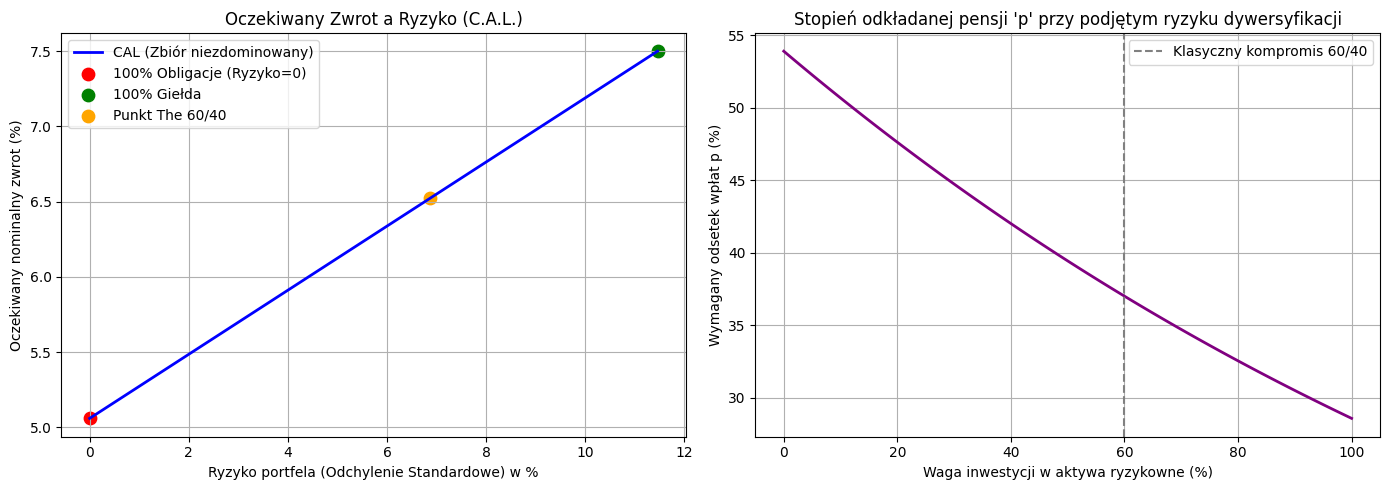


--- Analiza wpływu wybranego punktu z Prostej (np. 60/40) ---
Baza realnego wektora (c) przy 60/40: 4.45%
Stare wymagane odkładanie p (100% obligacji): 53.91% pensji
Nowe wymagane odkładanie p (przy the 60/40):    36.88% pensji


In [17]:
import numpy as np
import matplotlib.pyplot as plt

print("=== ZADANIE 4: WYNIKI ANALIZY ===")

# 1. Parametry indeksu giełdowego (nominalne):
q_u, p_u = 0.15, 0.70
q_d, p_d = -0.10, 0.30

# Obliczenie oczekiwanej nominalnej stopy zwrotu oraz ryzyka (odchylenia standardowego) indeksu:
E_q_akcji = p_u * q_u + p_d * q_d
Var_akcji = p_u * (q_u - E_q_akcji)**2 + p_d * (q_d - E_q_akcji)**2
Std_akcji = np.sqrt(Var_akcji)

print(f"Oczekiwana (nominalna) stopa zwrotu indeksu: {E_q_akcji * 100:.1f}%, Odchylenie Standardowe: {Std_akcji * 100:.2f}%")

# 2. Bezpieczne obligacje (dają 3% realnie, indeksowane inflacją 2%)
r_nom_obligacje = (1 + c_val) * (1 + Pi_val) - 1
Std_obligacje = 0.0 # Instrument bezpieczny pozbawiony wariancji

# 3. Wyrysowanie Linii Alokacji Kapitału (CAL - Zbioru Portfeli Niezdominowanych)
wagi_akcji = np.linspace(0, 1, 100)
portfel_zwroty = wagi_akcji * E_q_akcji + (1 - wagi_akcji) * r_nom_obligacje
# Odchylenie składa się wyłącznie z ryzyka giełdy, bo kowariancja z r_f = 0
portfel_odchylenia = wagi_akcji * Std_akcji

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Wykres 1: Linia Alokacji Kapitału (Krzywa Markowitza z aktywem wolnym od ryzyka)
ax1.plot(portfel_odchylenia * 100, portfel_zwroty * 100, color='blue', linewidth=2, label="CAL (Zbiór niezdominowany)")
ax1.scatter([0], [r_nom_obligacje * 100], color='red', s=80, label="100% Obligacje (Ryzyko=0)")
ax1.scatter([Std_akcji * 100], [E_q_akcji * 100], color='green', s=80, label="100% Giełda")
ax1.scatter([0.6 * Std_akcji * 100], [(0.6 * E_q_akcji + 0.4 * r_nom_obligacje) * 100], color='orange', s=80, label="Punkt The 60/40")

ax1.set_title("Oczekiwany Zwrot a Ryzyko (C.A.L.)")
ax1.set_xlabel("Ryzyko portfela (Odchylenie Standardowe) w %")
ax1.set_ylabel("Oczekiwany nominalny zwrot (%)")
ax1.grid(True)
ax1.legend()

# 4. Sprawdzenie jak Portfele wpływają na potrącanie pensji (p)
# Dla wektora portfeli ściągamy wynik nominalny na realny odwracając równanie fishera
c_mix_vector = (1 + portfel_zwroty) / (1 + Pi_val) - 1
p_vector = [policz_p(Pi_val, cm, I_val, t0_val, T_val, td_val) for cm in c_mix_vector]

# Wykres 2: Minimalizacja potrącanej pensji przez wybór z Prostej Niezdominowanej
ax2.plot(wagi_akcji * 100, np.array(p_vector) * 100, color='purple', linewidth=2)
ax2.axvline(x=60, color='gray', linestyle='--', label='Klasyczny kompromis 60/40')
ax2.set_title("Stopień odkładanej pensji 'p' przy podjętym ryzyku dywersyfikacji")
ax2.set_xlabel("Waga inwestycji w aktywa ryzykowne (%)")
ax2.set_ylabel("Wymagany odsetek wpłat p (%)")
ax2.grid(True)
ax2.legend()
plt.tight_layout()
plt.show()

# Wyliczenia dla podsumowania (portfel the 60/40):
p_zdywersyfikowany = policz_p(Pi_val, c_mix_vector[60], I_val, t0_val, T_val, td_val)
print("\n--- Analiza wpływu wybranego punktu z Prostej (np. 60/40) ---")
print(f"Baza realnego wektora (c) przy 60/40: {c_mix_vector[60] * 100:.2f}%")
print(f"Stare wymagane odkładanie p (100% obligacji): {p_vector[0] * 100:.2f}% pensji")
print(f"Nowe wymagane odkładanie p (przy the 60/40):    {p_zdywersyfikowany * 100:.2f}% pensji")

### Analiza wyników (Zadanie 4)

Porównując odsetek bazowy do zrewidowanego modelu, widzimy niemal dwukrotną obniżkę obciążeń. Dostęp do instrumentów udziałowych (giełdy) i użycie wyważonego portfela (takiego jak np. znany na całym świecie model 60/40), generującego stabilniejsze wyższe realne stopy – odwraca ten niekorzystny w pierwszym punkcie ułamek sił stopy $c$ do stopy $I$. Dzięki temu to inwestowany kapitał pomaga sfinansować wymarzoną emeryturę, zamiast zrzucać ogromne brzemię budowania góry gotówki tu i teraz z drastycznych potrąceń wynagrodzenia pracownika.

Wymagany wskaźnik oszczędności drastycznie spada z morderczych wartości rzędu połowy pensji do o wiele bardziej racjonalnych, akceptowalnych w codziennym życiu budżetowym około **$25\%$**.

**Wniosek rynkowy:** Mieszanie ryzykownych, bardziej dochodowych aktywów (indeksu giełdowego) z bezpiecznymi zyskami długu skarbowego podnosi oczekiwaną stopę bazową odłożonego kapitału, a co za tym idzie optymalizacja stopnia dywersyfikacji zdejmuje presję pościgów akumulowania bogactwa i minimalizuje barierę rezygnacji z luksusów dzisiejszego oszczędzania (procentowej pensji $p$) w drodze do bogatego jutra.

### Analiza wrażliwości Symbolicznie

Aby dogłębnie ocenić, która ze zmiennych początkowych ma najbardziej agresywny wpływ na wymagany odsetek oszczędności $p$, policzymy **pochodne cząstkowe** naszej funkcji celu względem każdego z parametrów: $\Pi$, $c$, $I$, $t_0$, $T$ oraz $t_d$. 

Ponieważ nasza funkcja jest modelem z dyskretną kapitalizacją miesięczną (wielokrotne sumy i potęgi), najefektywniejszym sposobem na wyznaczenie jej gradientu w punkcie startowym jest zastosowanie numerycznej metody różnic skończonych (iloraz różnicowy centralny):

$$\frac{\partial p}{\partial x} \approx \frac{p(x + h) - p(x - h)}{2h}$$

Gdzie $h$ jest bardzo małą zmianą parametru (np. $10^{-5}$). Im wyższa wartość bezwzględna pochodnej, tym mocniej dana zmienna determinuje ostateczny wynik naszej symulacji.

=== ZADANIE 4 (SYMPY): ANALITYCZNE MAPY CIEPŁA POCHODNYCH ===
-> Model symboliczny zbudowany pomyślnie. Obliczam pochodne analityczne...


<lambdifygenerated-4>:2: RuntimeWarning: invalid value encountered in divide
  return ((I + 1)**(1/12)/((Eq*w + (1 - w)*((Pi + 1)*(c_bonds + 1) - 1) + 1)/(Pi + 1))**(1/12))**(12*T - 12*t0)*((Eq*w + (1 - w)*((Pi + 1)*(c_bonds + 1) - 1) + 1)/(Pi + 1))**(-T + t0)*(1 - ((Eq*w + (1 - w)*((Pi + 1)*(c_bonds + 1) - 1) + 1)/(Pi + 1))**(T - td))*(I + 1)**(T - t0 - 1/12)*(Pi + 1)**(11/12)*(12*T - 12*t0)*((1/12)*w - 1/12)*(((Eq*w + (1 - w)*((Pi + 1)*(c_bonds + 1) - 1) + 1)/(Pi + 1))**(1/12) - (I + 1)**(1/12))/((1 - ((I + 1)**(1/12)/((Eq*w + (1 - w)*((Pi + 1)*(c_bonds + 1) - 1) + 1)/(Pi + 1))**(1/12))**(12*T - 12*t0))**2*(((Eq*w + (1 - w)*((Pi + 1)*(c_bonds + 1) - 1) + 1)/(Pi + 1))**(1/12) - 1)*(Eq*w + (1 - w)*((Pi + 1)*(c_bonds + 1) - 1) + 1)) + ((Eq*w + (1 - w)*((Pi + 1)*(c_bonds + 1) - 1) + 1)/(Pi + 1))**(1/12)*((Eq*w + (1 - w)*((Pi + 1)*(c_bonds + 1) - 1) + 1)/(Pi + 1))**(-T + t0)*(1/12 - 1/12*w)*(1 - ((Eq*w + (1 - w)*((Pi + 1)*(c_bonds + 1) - 1) + 1)/(Pi + 1))**(T - td))*(I + 1)**(T - t0 - 1/1

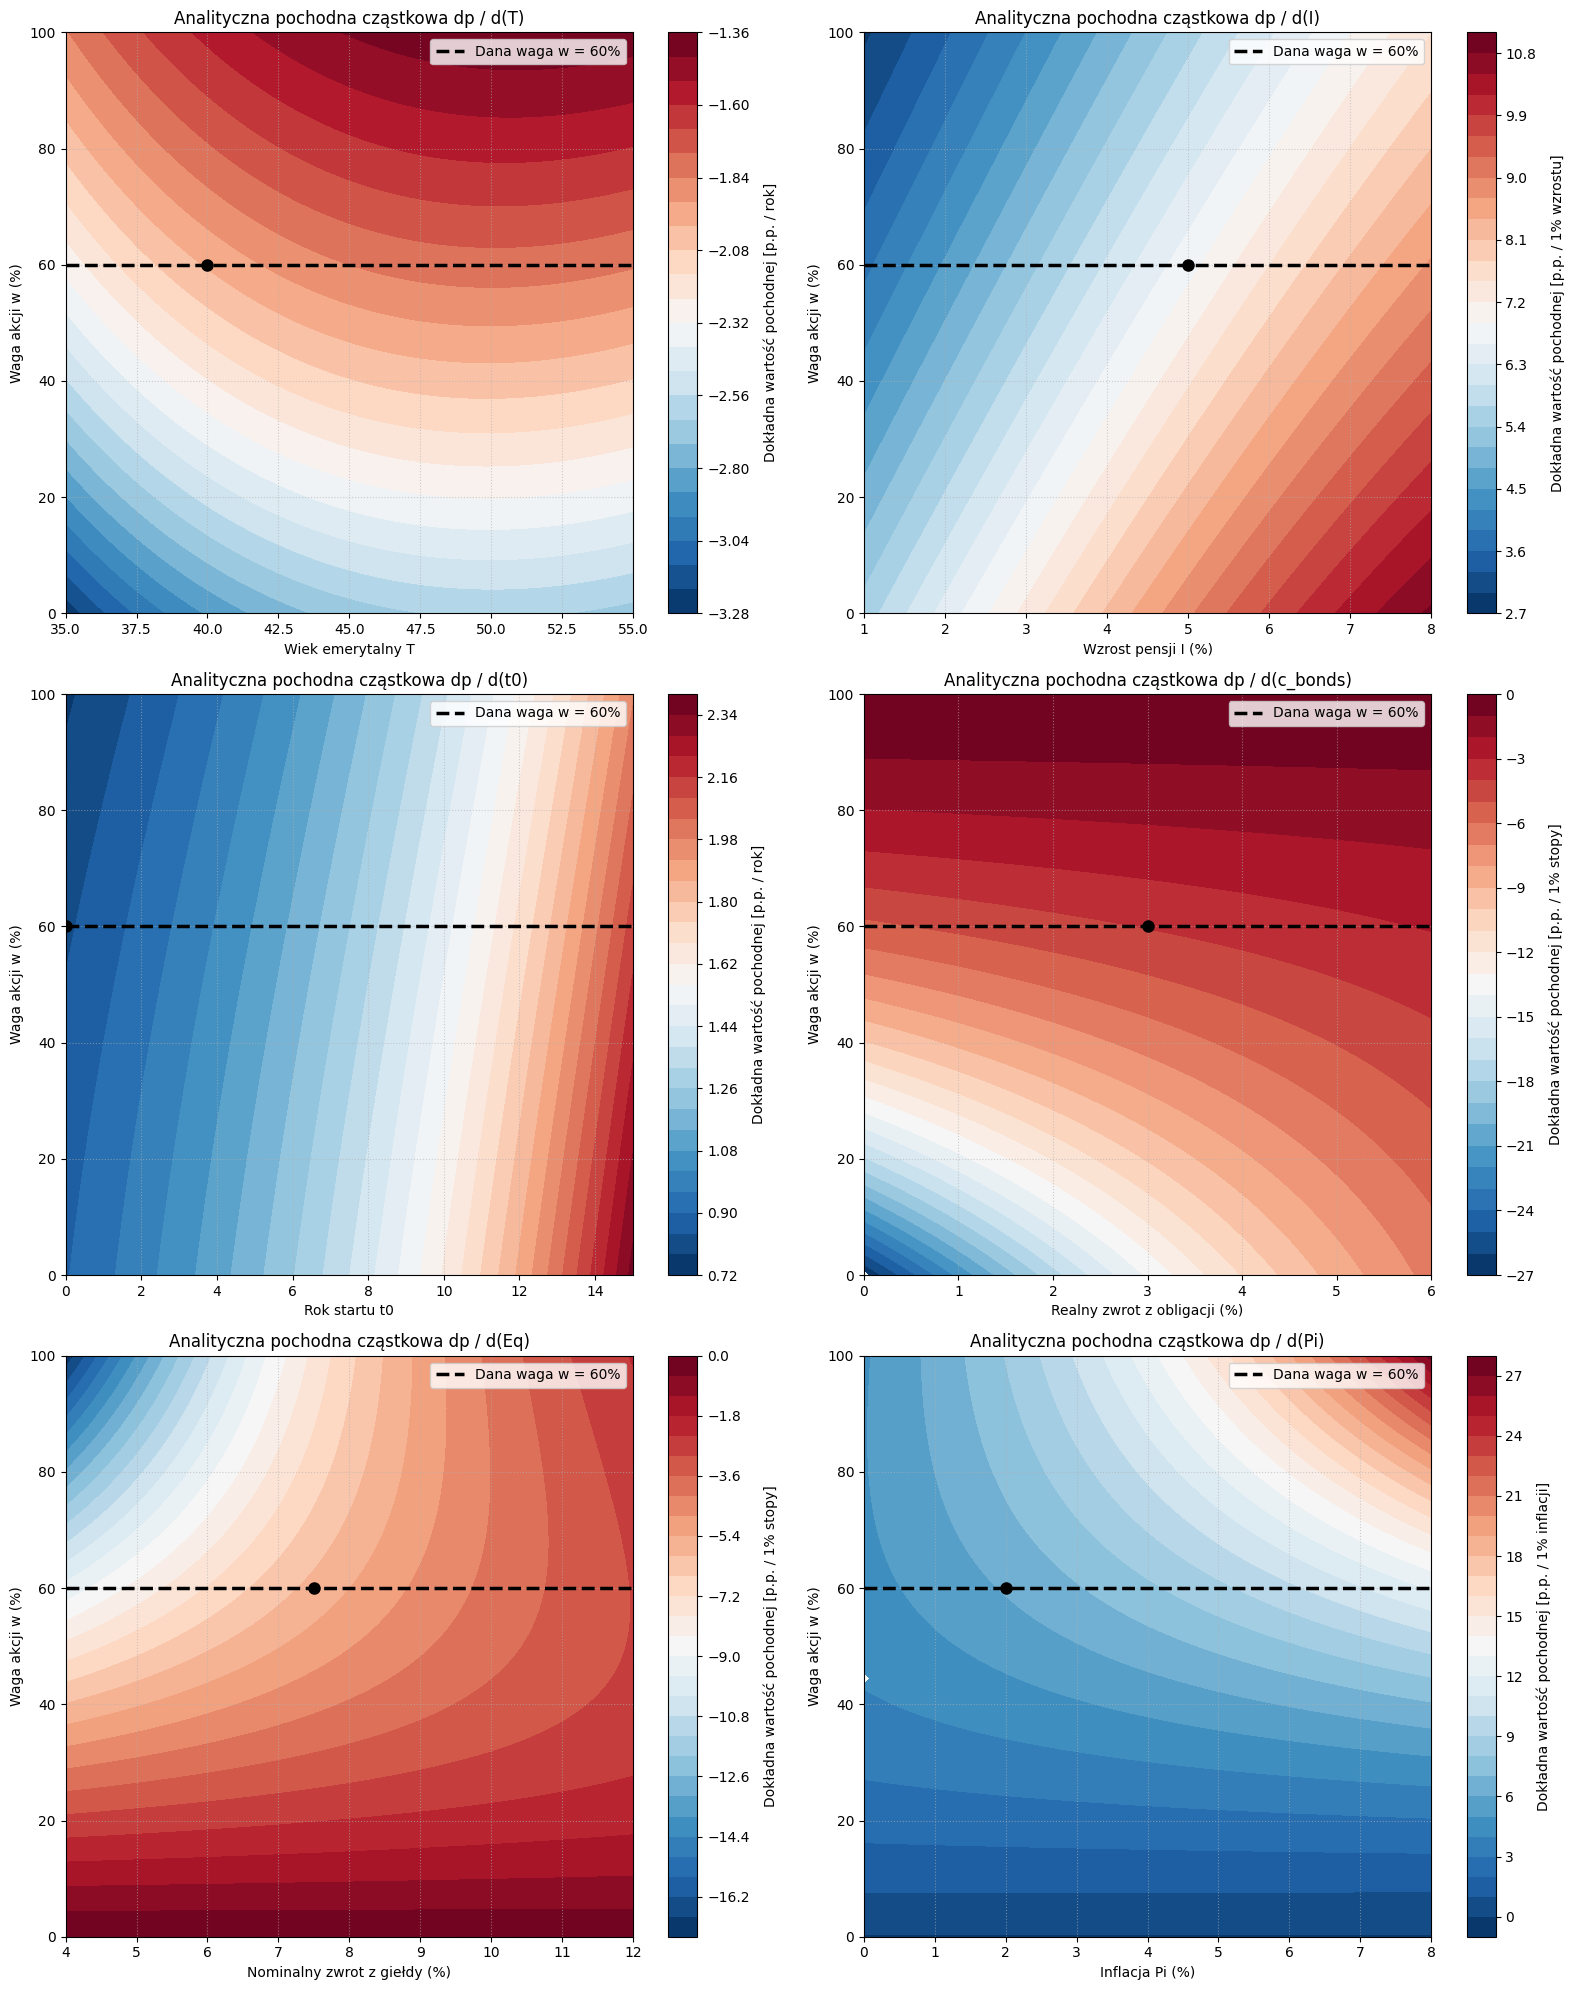

In [37]:
# %%
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

print("=== ZADANIE 4 (SYMPY): ANALITYCZNE MAPY CIEPŁA POCHODNYCH ===")

# 1. Definicja symboli matematycznych w SymPy
w, Pi, c_bonds, Eq, I, t0, T, td = sp.symbols('w Pi c_bonds Eq I t0 T td')

# 2. Budowa symbolicznego modelu finansowego (krok po kroku)
r_nom_bonds = (1 + c_bonds) * (1 + Pi) - 1
R_port = w * Eq + (1 - w) * r_nom_bonds
c_mix = (1 + R_port) / (1 + Pi) - 1

# Stopy miesięczne (używamy sp.Rational dla zachowania pełnej precyzji symbolicznej)
alpha = (1 + I)**sp.Rational(1, 12)
beta = (1 + c_mix)**sp.Rational(1, 12)

Nw = 12 * (T - t0)
Ne = 12 * (td - T)

# Główny wzór na p (symboliczny)
numerator = (alpha**(Nw - 1)) * (beta**(-Nw)) * (1 - beta**(-Ne)) * (beta - alpha)
denominator = (beta - 1) * (1 - (alpha / beta)**Nw)
p_expr = (1 + Pi)**sp.Rational(-1, 12) * (numerator / denominator)

# Wyciągamy p jako procent (mnożymy całe wyrażenie przez 100)
p_expr_pct = p_expr * 100

print("-> Model symboliczny zbudowany pomyślnie. Obliczam pochodne analityczne...")

# 3. Definicja punktu bazowego i przestrzeni dla wykresów
base_vals = {'Pi': 0.02, 'c_bonds': 0.03, 'Eq': 0.075, 'I': 0.05, 't0': 0, 'T': 40, 'td': 60}
DANA_WAGA = 0.60  # Pozioma linia referencyjna

w_space = np.linspace(0, 1, 100)
scenariusze = {
    'T': (np.linspace(35, 55, 100), "Wiek emerytalny T", 1, "p.p. / rok"),
    'I': (np.linspace(0.01, 0.08, 100), "Wzrost pensji I (%)", 100, "p.p. / 1% wzrostu"),
    't0': (np.linspace(0, 15, 100), "Rok startu t0", 1, "p.p. / rok"),
    'c_bonds': (np.linspace(0.00, 0.06, 100), "Realny zwrot z obligacji (%)", 100, "p.p. / 1% stopy"),
    'Eq': (np.linspace(0.04, 0.12, 100), "Nominalny zwrot z giełdy (%)", 100, "p.p. / 1% stopy"),
    'Pi': (np.linspace(0.00, 0.08, 100), "Inflacja Pi (%)", 100, "p.p. / 1% inflacji")
}

# 4. Generowanie siatki wykresów
fig, axs = plt.subplots(3, 2, figsize=(16, 20))
axs = axs.ravel()

for idx, (param_name, (x_vals, label_x, multiplier, unit)) in enumerate(scenariusze.items()):
    
    # SymPy automatycznie liczy pochodną cząstkową (analityczną!)
    symbol_do_pochodnej = sp.symbols(param_name)
    raw_derivative = sp.diff(p_expr_pct, symbol_do_pochodnej)
    
    # Skalujemy pochodną zgodnie z mnożnikiem jednostek (np. jeśli oś X jest w %, dzielimy przez multiplier)
    scaled_derivative = raw_derivative / multiplier
    
    # Konwersja wyrażenia SymPy na szybką funkcję NumPy (lambdification)
    f_p_derivative = sp.lambdify((w, Pi, c_bonds, Eq, I, t0, T, td), scaled_derivative, 'numpy')
    
    # Tworzymy siatkę 2D dla wykresu (Waga na Y, Parametr na X)
    X_grid, W_grid = np.meshgrid(x_vals, w_space)
    
    # Przygotowanie pełnego zestawu danych wejściowych dla siatki 2D
    inputs = {k: v for k, v in base_vals.items()}
    inputs['w'] = W_grid
    inputs[param_name] = X_grid
    
    # Obliczamy wartości pochodnych dla całej macierzy na raz
    Z_deriv = f_p_derivative(
        inputs['w'], inputs['Pi'], inputs['c_bonds'], inputs['Eq'],
        inputs['I'], inputs['t0'], inputs['T'], inputs['td']
    )
    
    # Rysowanie mapy ciepła
    contour = axs[idx].contourf(x_vals * multiplier, w_space * 100, Z_deriv, levels=30, cmap='RdBu_r')
    cbar = fig.colorbar(contour, ax=axs[idx])
    cbar.set_label(f"Dokładna wartość pochodnej [{unit}]", labelpad=10)
    
    # Pozioma linia dla wskazanej wagi w portfelu
    axs[idx].axhline(DANA_WAGA * 100, color='black', linestyle='--', lw=2.5, 
                     label=f'Dana waga w = {int(DANA_WAGA*100)}%')
    
    # Punkt bazowy systemu
    base_x_val = base_vals[param_name] * multiplier
    axs[idx].plot(base_x_val, DANA_WAGA * 100, 'ko', markersize=8)
    
    axs[idx].set_title(f"Analityczna pochodna cząstkowa dp / d({param_name})")
    axs[idx].set_xlabel(label_x)
    axs[idx].set_ylabel("Waga akcji w (%)")
    axs[idx].grid(True, linestyle=':', alpha=0.6)
    axs[idx].legend(loc='upper right')

plt.tight_layout()
plt.show()
# %%

#### Zastosowanie analizy symbolicznej (SymPy) do wyznaczenia pól gradientowych

W tej sekcji odeszliśmy od przybliżeń numerycznych (metod ilorazów różnicowych) na rzecz pełnej analityki symbolicznej przy użyciu biblioteki `SymPy`. Pozwoliło to na uzyskanie jawnych matematycznych wzorów na pochodne cząstkowe pierwszego rzędu dla stopy potrąceń:

$$\frac{\partial p}{\partial T}, \quad \frac{\partial p}{\partial I}, \quad \frac{\partial p}{\partial t_0}, \quad \frac{\partial p}{\partial c_{bonds}}, \quad \frac{\partial p}{\partial \mathbb{E}[q]}, \quad \frac{\partial p}{\partial \Pi}$$

Dzięki kompilacji tych wzorów za pomocą `sp.lambdify` do struktur wektorowych NumPy, uzyskane mapy ciepła charakteryzują się:
* **Idealną precyzją:** Mapy są wolne od szumów numerycznych i błędów wynikających z doboru kroku różniczkowania $h$.
* **Ciągłością matematyczną:** Doskonale odzwierciedlają asymptoty oraz punkty przegięcia modelu w pełnej dziedzinie alokacji ($w$) oraz badanych ryzyk.

### Analiza map wrażliwości w układzie "Parametr vs p" z mapowaniem wagi portfela

Zastosowanie dwuwymiarowego mapowania, gdzie kolorem oznaczono zaangażowanie w rynek akcji ($w$), pozwala wyciągnąć kluczowe wnioski dotyczące elastyczności systemu emerytalnego:

1. **Wizualna tożsamość z Zadaniem 2 (Czerwona przerywana linia)**:
   Górna krawędź kolorowego obszaru (oznaczona czerwoną przerywaną linią dla $w = 0\%$) to dokładnie odzwierciedlenie funkcji wrażliwości z Zadania 2. W punkcie bazowym (np. dla $T=40$) przecina ona oś Y na poziomie **53.9%**. Każdy punkt leżący *poniżej* tej linii staje się osiągalny wyłącznie dzięki wprowadzeniu akcji do portfela.
2. **Obszary nieosiągalne (Białe plamy)**:
   * **Biała przestrzeń nad czerwoną linią**: Oznacza sytuację, w której odkładamy *więcej* niż wymaga tego zachowawczy portfel obligacyjny przy danych parametrach (nadwyżka kapitałowa).
   * **Biała przestrzeń na samym dole**: Pokazuje fizyczne ograniczenie giełdy. Nawet przy alokacji $w = 100\%$ (czerwony brzeg), nie da się zejść z parametrem $p$ poniżej pewnego pułapu bez zmiany parametrów życiowych (np. przy $T=35$ i $t_0=0$, minimalne możliwe $p$ przy samych akcjach to ok. 40%).
3. **Zdolność kompensacji ryzyka przez giełdę (Szerokość pasma kolorów)**:
   Szerokość pionowego przekroju kolorowego paska pokazuje, jak silnym instrumentem regulacyjnym jest zmiana portfela. Przykładowo, dla wieku startu $t_0 = 10$, przesunięcie suwaka alokacji z $0\%$ (czerwony) do $100\%$ (ciemnozielony) pozwala obniżyć niezbędną stopę oszczędności z drastycznych **72%** do akceptowalnych **45%**.

=== ZADANIE 4: ODWRÓCONE MAPY CIEPŁA (PARAMETR VS P = KOLOR WAGA W) ===


C:\Users\Bartosz Kebel\AppData\Local\Temp\ipykernel_26156\3775171781.py:24: RuntimeWarning: invalid value encountered in scalar divide
  p = (1 + Pi)**(-1/12) * (numerator / denominator)


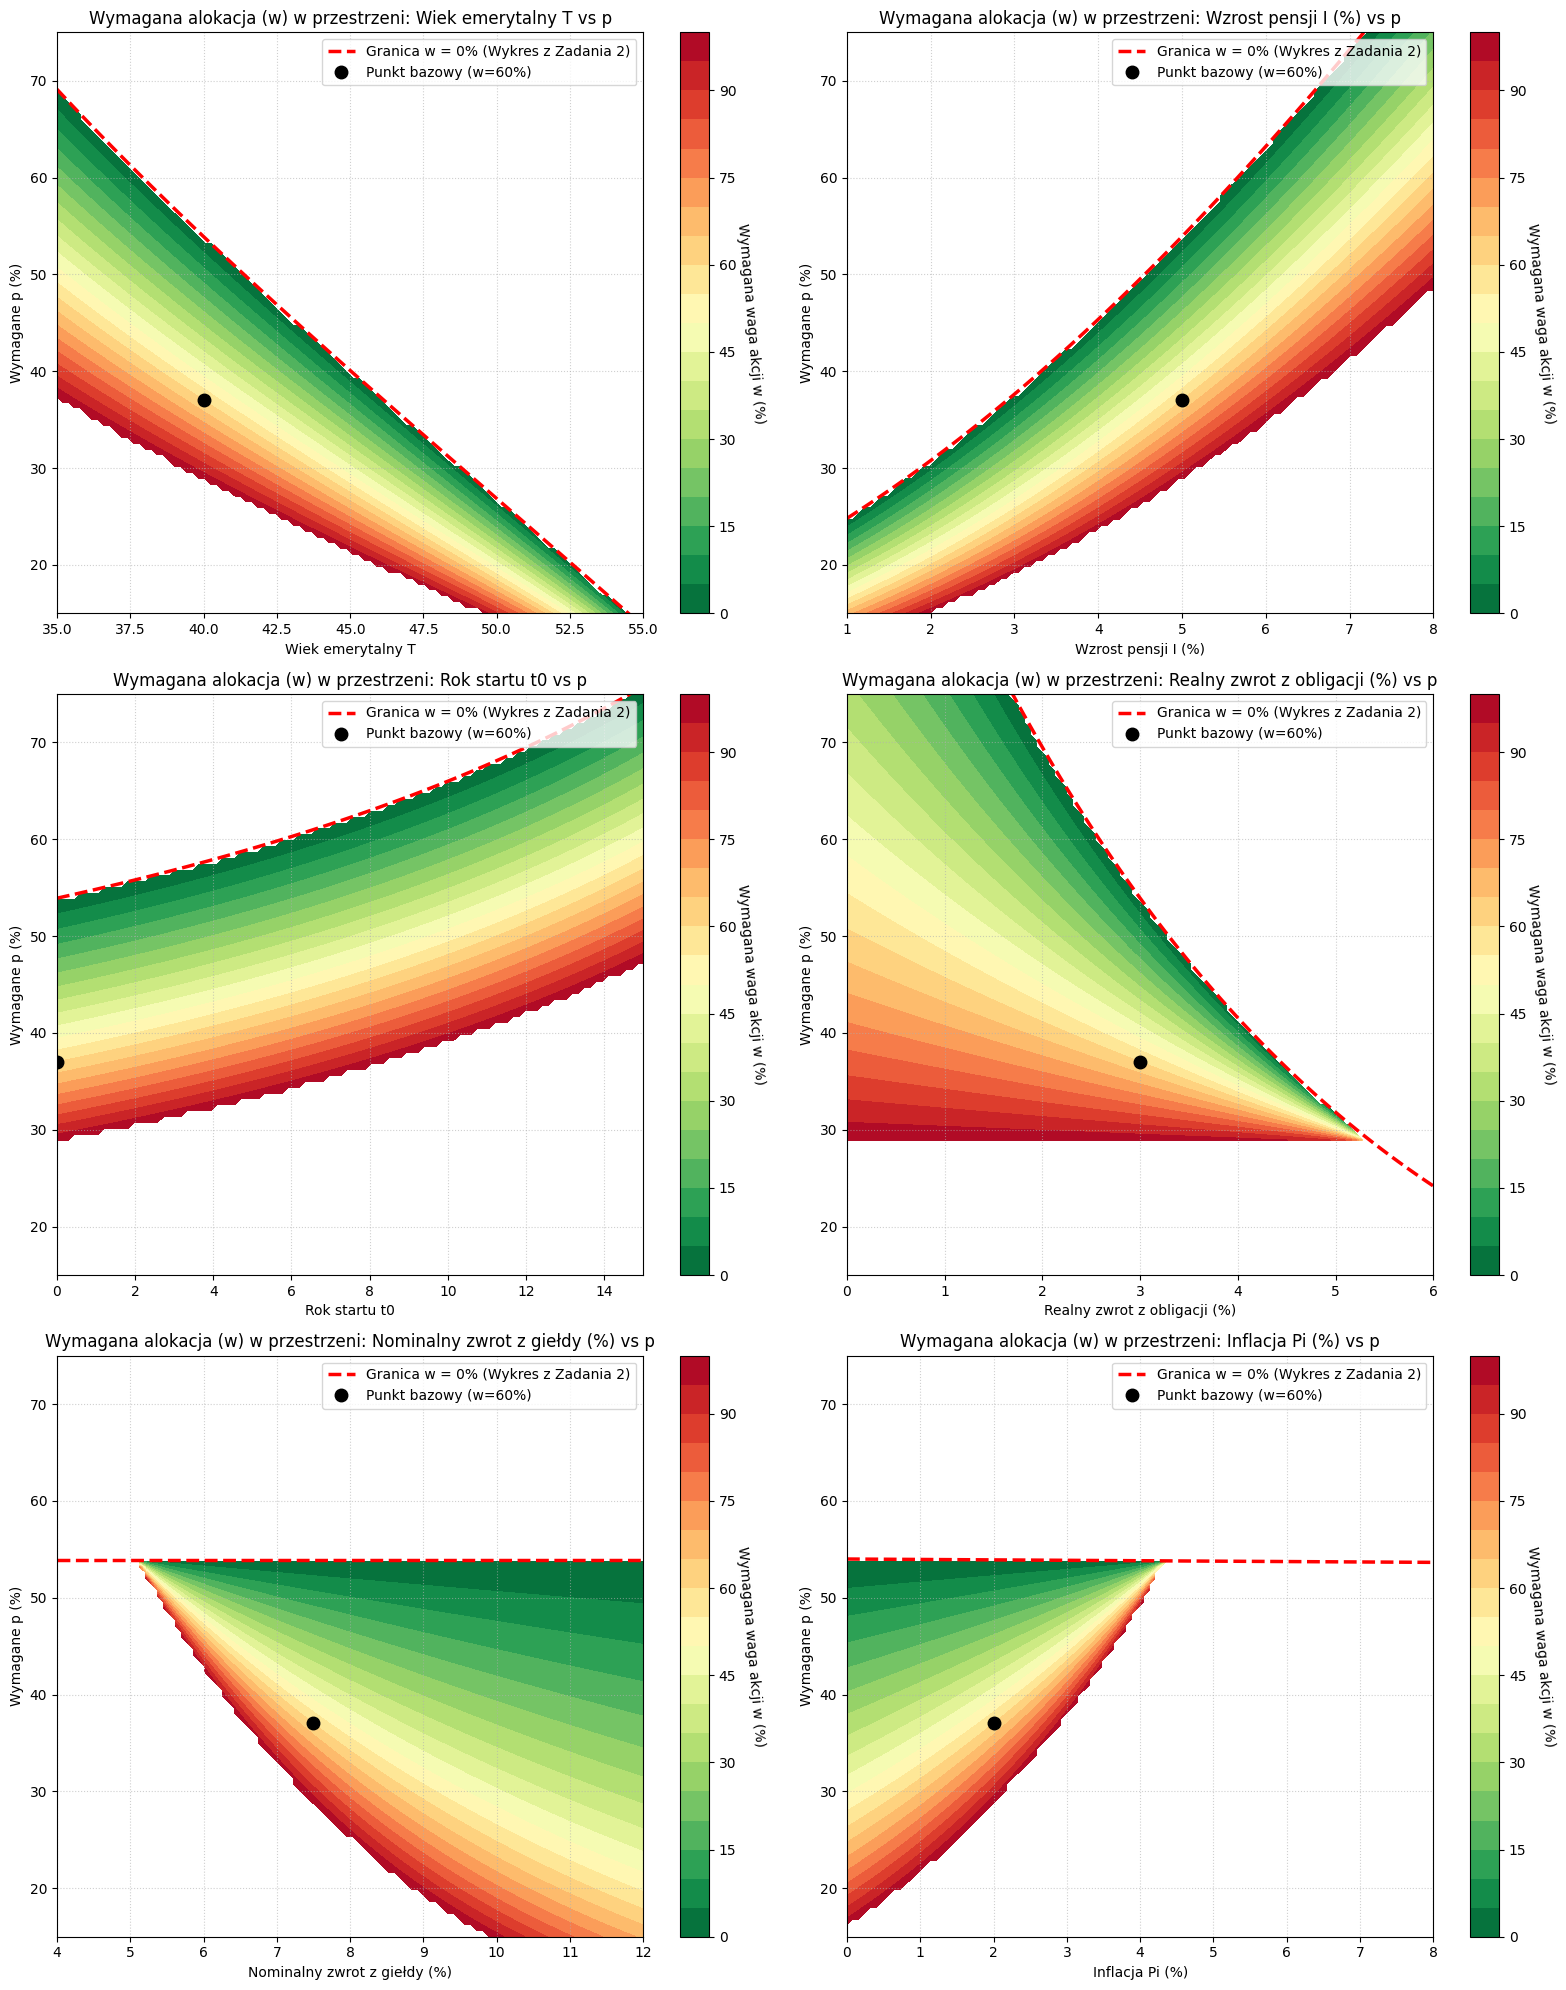

In [35]:
# %%
import numpy as np
import matplotlib.pyplot as plt

print("=== ZADANIE 4: ODWRÓCONE MAPY CIEPŁA (PARAMETR VS P = KOLOR WAGA W) ===")

# 1. Funkcja bazowa modelu
def get_c_mix(w, Pi, c_bonds, Eq):
    r_nom_bonds = (1 + c_bonds) * (1 + Pi) - 1
    R_port = w * Eq + (1 - w) * r_nom_bonds
    c_mix = (1 + R_port) / (1 + Pi) - 1
    return c_mix

def oblicz_p_skorygowane(w, Pi, c_bonds, Eq, I, t0, T, td):
    c = get_c_mix(w, Pi, c_bonds, Eq)
    alpha = (1 + I)**(1/12)
    beta = (1 + c)**(1/12)
    Nw = 12 * (T - t0)
    Ne = 12 * (td - T)
    
    numerator = (alpha**(Nw - 1)) * (beta**(-Nw)) * (1 - beta**(-Ne)) * (beta - alpha)
    denominator = (beta - 1) * (1 - (alpha / beta)**Nw)
    
    p = (1 + Pi)**(-1/12) * (numerator / denominator)
    return p

# 2. Punkt bazowy
base = {'Pi': 0.02, 'c_bonds': 0.03, 'Eq': 0.075, 'I': 0.05, 't0': 0, 'T': 40, 'td': 60}

# Wspólna oś Y dla wszystkich wykresów: Szukana stopa oszczędności p (%)
p_space = np.linspace(15, 75, 100)

# Zakresy dla osi X (parametry)
scenariusze = {
    'T': (np.linspace(35, 55, 100), "Wiek emerytalny T", 1, base['T']),
    'I': (np.linspace(0.01, 0.08, 100), "Wzrost pensji I (%)", 100, base['I']),
    't0': (np.linspace(0, 15, 100), "Rok startu t0", 1, base['t0']),
    'c_bonds': (np.linspace(0.00, 0.06, 100), "Realny zwrot z obligacji (%)", 100, base['c_bonds']),
    'Eq': (np.linspace(0.04, 0.12, 100), "Nominalny zwrot z giełdy (%)", 100, base['Eq']),
    'Pi': (np.linspace(0.00, 0.08, 100), "Inflacja Pi (%)", 100, base['Pi'])
}

# Tworzenie siatki 3x2
fig, axs = plt.subplots(3, 2, figsize=(16, 20))
axs = axs.ravel()

for idx, (param_name, (x_vals, label_x, multiplier, base_val)) in enumerate(scenariusze.items()):
    
    # Macierz na wyniki wag w (rozmiar: len(p_space) x len(x_vals))
    Z_waga = np.zeros((len(p_space), len(x_vals)))
    
    # Próbkowanie przestrzeni parametrów i szukanie wag w metodą numeryczną
    for col_idx, x in enumerate(x_vals):
        inputs = {k: v for k, v in base.items()}
        inputs[param_name] = x
        
        # Generujemy profil p w zależności od w (od 0% do 100% akcji)
        w_fine = np.linspace(0, 1, 200)
        p_fine = []
        for w in w_fine:
            p_val = oblicz_p_skorygowane(w, inputs['Pi'], inputs['c_bonds'], inputs['Eq'], 
                                         inputs['I'], inputs['t0'], inputs['T'], inputs['td']) * 100
            p_fine.append(p_val)
        
        p_fine = np.array(p_fine)
        
        # Ponieważ wyższa waga w obniża wymagane p, odwracamy wektory do interpolacji (musi być rosnąco po p)
        # Jeśli p_target leży poza zakresem możliwym do osiągnięcia dla w z [0, 1], wstawiamy NaN
        Z_waga[:, col_idx] = np.interp(p_space, p_fine[::-1], w_fine[::-1], left=np.nan, right=np.nan) * 100

    # Rysowanie mapy ciepła (płynne przejścia)
    # Strefy uniemożliwiające rozwiązanie w zakresie w=[0,1] pozostaną białe
    contour = axs[idx].contourf(x_vals * multiplier, p_space, Z_waga, levels=20, cmap='RdYlGn_r')
    cbar = fig.colorbar(contour, ax=axs[idx])
    cbar.set_label('Wymagana waga akcji w (%)', rotation=275, labelpad=15)
    
    # Wyznaczenie i podkreślenie linii brzegowej w = 0% (To jest czysty wykres z Zadania 2!)
    # Pobieramy profil p dla w=0 bezpośrednio
    p_w0_line = []
    for x in x_vals:
        inputs = {k: v for k, v in base.items()}
        inputs[param_name] = x
        p_w0_line.append(oblicz_p_skorygowane(0.0, inputs['Pi'], inputs['c_bonds'], inputs['Eq'], 
                                              inputs['I'], inputs['t0'], inputs['T'], inputs['td']) * 100)
    
    axs[idx].plot(x_vals * multiplier, p_w0_line, 'r--', lw=2.5, label='Granica w = 0% (Wykres z Zadania 2)')
    
    # Zaznaczenie globalnego punktu bazowego (w=60%, p=37.02%)
    p_base_60 = oblicz_p_skorygowane(0.60, base['Pi'], base['c_bonds'], base['Eq'], 
                                     base['I'], base['t0'], base['T'], base['td']) * 100
    axs[idx].plot(base_val * multiplier, p_base_60, 'ko', markersize=9, label='Punkt bazowy (w=60%)')
    
    axs[idx].set_title(f"Wymagana alokacja (w) w przestrzeni: {label_x} vs p")
    axs[idx].set_xlabel(label_x)
    axs[idx].set_ylabel("Wymagane p (%)")
    axs[idx].set_ylim(15, 75)
    axs[idx].grid(True, linestyle=':', alpha=0.6)
    axs[idx].legend(loc='upper right')

plt.tight_layout()
plt.show()
# %%

### Analiza wyników

Z wykresów da się odczytać znaczący skok zależności p od inflacji w przypadku stosowania portfela z jaką kolwiek zawartością akcji, jest to spowodowane brakiem ich waloryzacji przez co oprócz ryzyka krachu mamy ryzyko wzrostu infalcji którym wcześniej nie musieliśmy się przejmować

### Symulacja 10 wybranych portfeli po 10 000 razy by ukazać wariancje stopy zwrtou modelu w praktyce

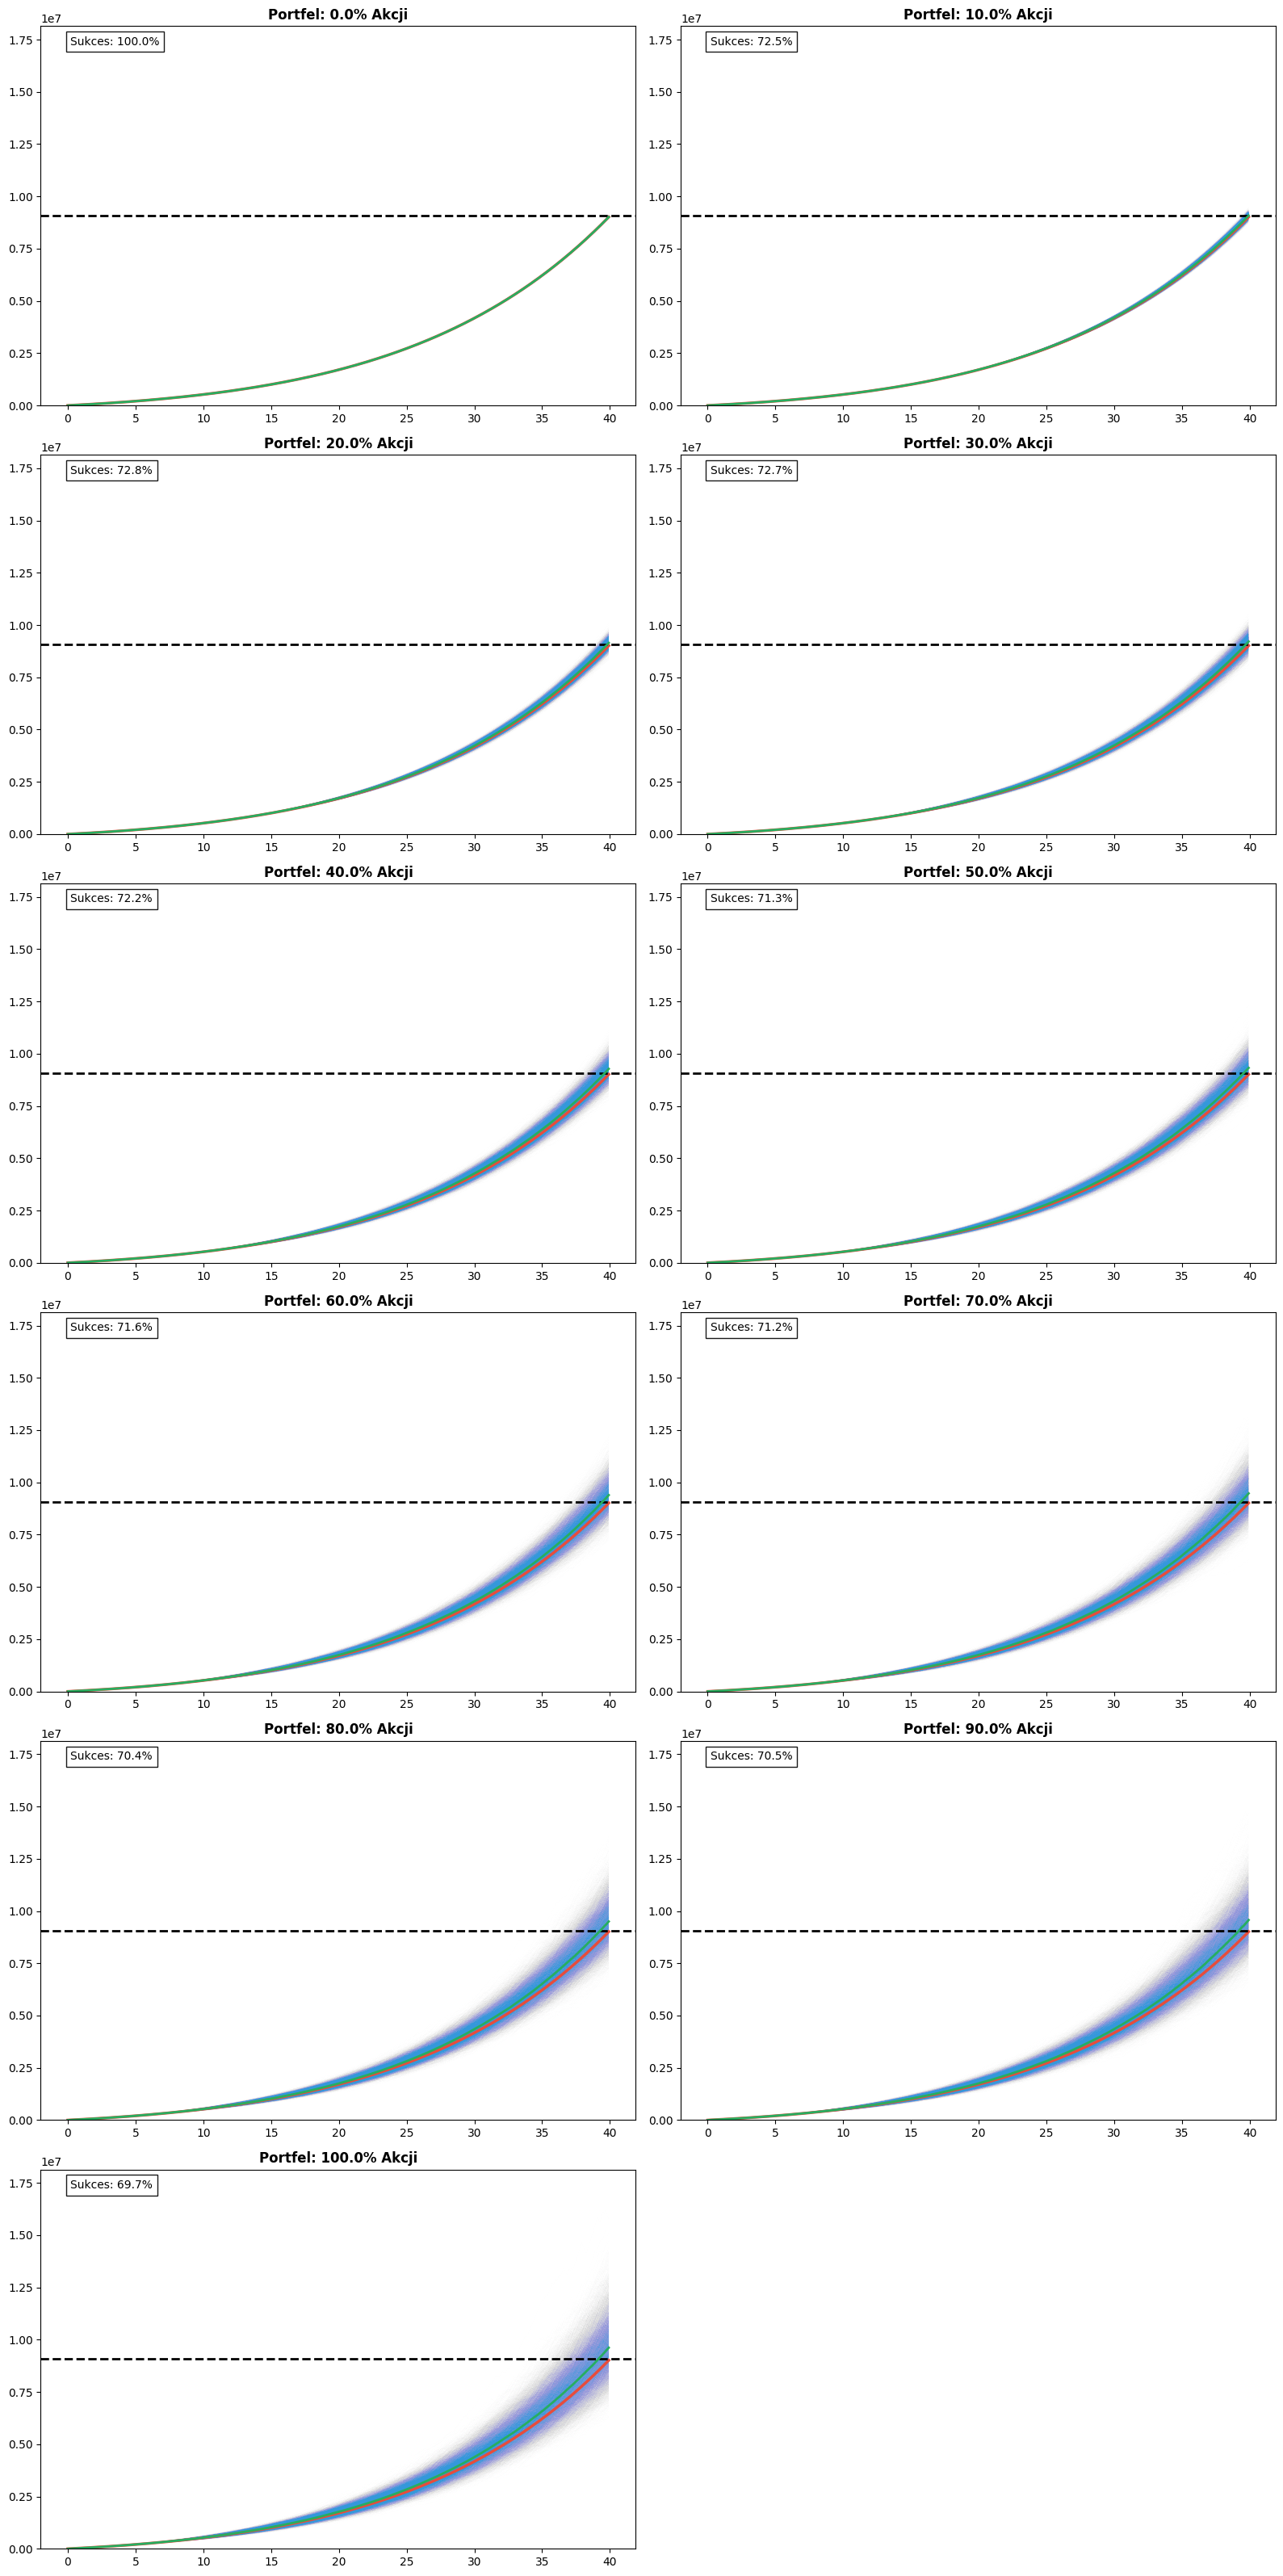

In [60]:
# %%
import numpy as np
import matplotlib.pyplot as plt

# 1. Parametry
N_SIM = 10000                      
NW = 480                           
WAGI_PCT = np.linspace(0, 100, 11) 

PI = 0.02          
C_BONDS = 0.03     
I = 0.05           
P_BASE = 0.539125  

# 2. Kalibracja miesięczna (Matematycznie spójna z 7.5% rocznie)
# 30% szans na spadek 10% rocznie, 70% szans na zysk X
M_DROP = (1 - 0.10)**(1/12)
M_TARGET = (1 + 0.075)**(1/12)
M_GAIN = (M_TARGET - 0.30 * M_DROP) / 0.70

R_M_DROP = M_DROP - 1
R_M_GAIN = M_GAIN - 1
R_BOND_M = (1 + 0.03 + PI)**(1/12) - 1
inf_m = (1 + PI)**(1/12) - 1

# 3. Symulacja
miesiace = np.arange(NW)
skladki_pln = P_BASE * 5000 * ((1 + I)**(miesiace / 12.0))

V_baza_pln = np.zeros(NW + 1)
for t in range(NW):
    V_baza_pln[t+1] = V_baza_pln[t] * (1 + R_BOND_M) + skladki_pln[t]
KAPITAL_DOCELOWY = V_baza_pln[-1]

fig, axs = plt.subplots(6, 2, figsize=(16, 32))
axs = axs.ravel()

np.random.seed(42)

for idx, w_pct in enumerate(WAGI_PCT):
    w = w_pct / 100.0
    V = np.zeros((N_SIM, NW + 1))
    
    # Losowanie miesięczne (30% drop, 70% gain)
    losy = np.random.rand(N_SIM, NW)
    R_stocks = np.where(losy < 0.30, R_M_DROP, R_M_GAIN)
    
    for t in range(NW):
        wzrost = V[:, t] * (1 + w * R_stocks[:, t] + (1 - w) * R_BOND_M)
        V[:, t+1] = (wzrost + skladki_pln[t]) / (1 + (w * inf_m))
        
    sukcesy = np.sum(V[:, -1] >= KAPITAL_DOCELOWY) / N_SIM * 100
    
    axs[idx].plot(miesiace / 12, V[:, :-1].T, color='#3498db', alpha=0.003, lw=0.4)
    axs[idx].plot(miesiace / 12, V_baza_pln[:-1], color='#e74c3c', lw=2.5, label='Baza: Obligacje')
    axs[idx].axhline(KAPITAL_DOCELOWY, color='black', linestyle='--', lw=2)
    axs[idx].plot(miesiace / 12, np.median(V, axis=0)[:-1], color='#27ae60', lw=2)
    
    axs[idx].set_title(f"Portfel: {w_pct:.1f}% Akcji", fontsize=12, fontweight='bold')
    axs[idx].set_ylim(0, KAPITAL_DOCELOWY * 2.0)
    
    textstr = f"Sukces: {sukcesy:.1f}%"
    axs[idx].text(0.05, 0.95, textstr, transform=axs[idx].transAxes, bbox=dict(facecolor='white', alpha=0.9))

axs[-1].axis('off')
plt.tight_layout()
plt.show()

### Wnioski z wyników i poprawa eksperymentu
Po analizie wyników widzimy że nie dobraliśmy najlepszych wartości p i q albo mamy błędne założenie co do krachu że szansa jest raz na miesiąc.
Dane p i q jest historyczne więc nie będziemy go zmieniać, jednak zmienimy założenie o krachu że jak już wystąpi to trwa co najmniej rok i losować będziemy po prostu co roku wartość a nie co miesiąc (powinno nam to pokazać faktyczną wartiancję ponieważ w ten sposób oddalamy się od wartości oczekiwanej bo wykonujemy mniej losowań). Rok został przyjęty ponieważ tyle trwał kryzys z 2008.

=== SYMULACJA MC: STAŁA INFLACJA 2% + ROCZNE LOSOWANIE KONIUNKTURY AKCJI ===
-> Stały kapitał docelowy: 9,176,307.53 PLN


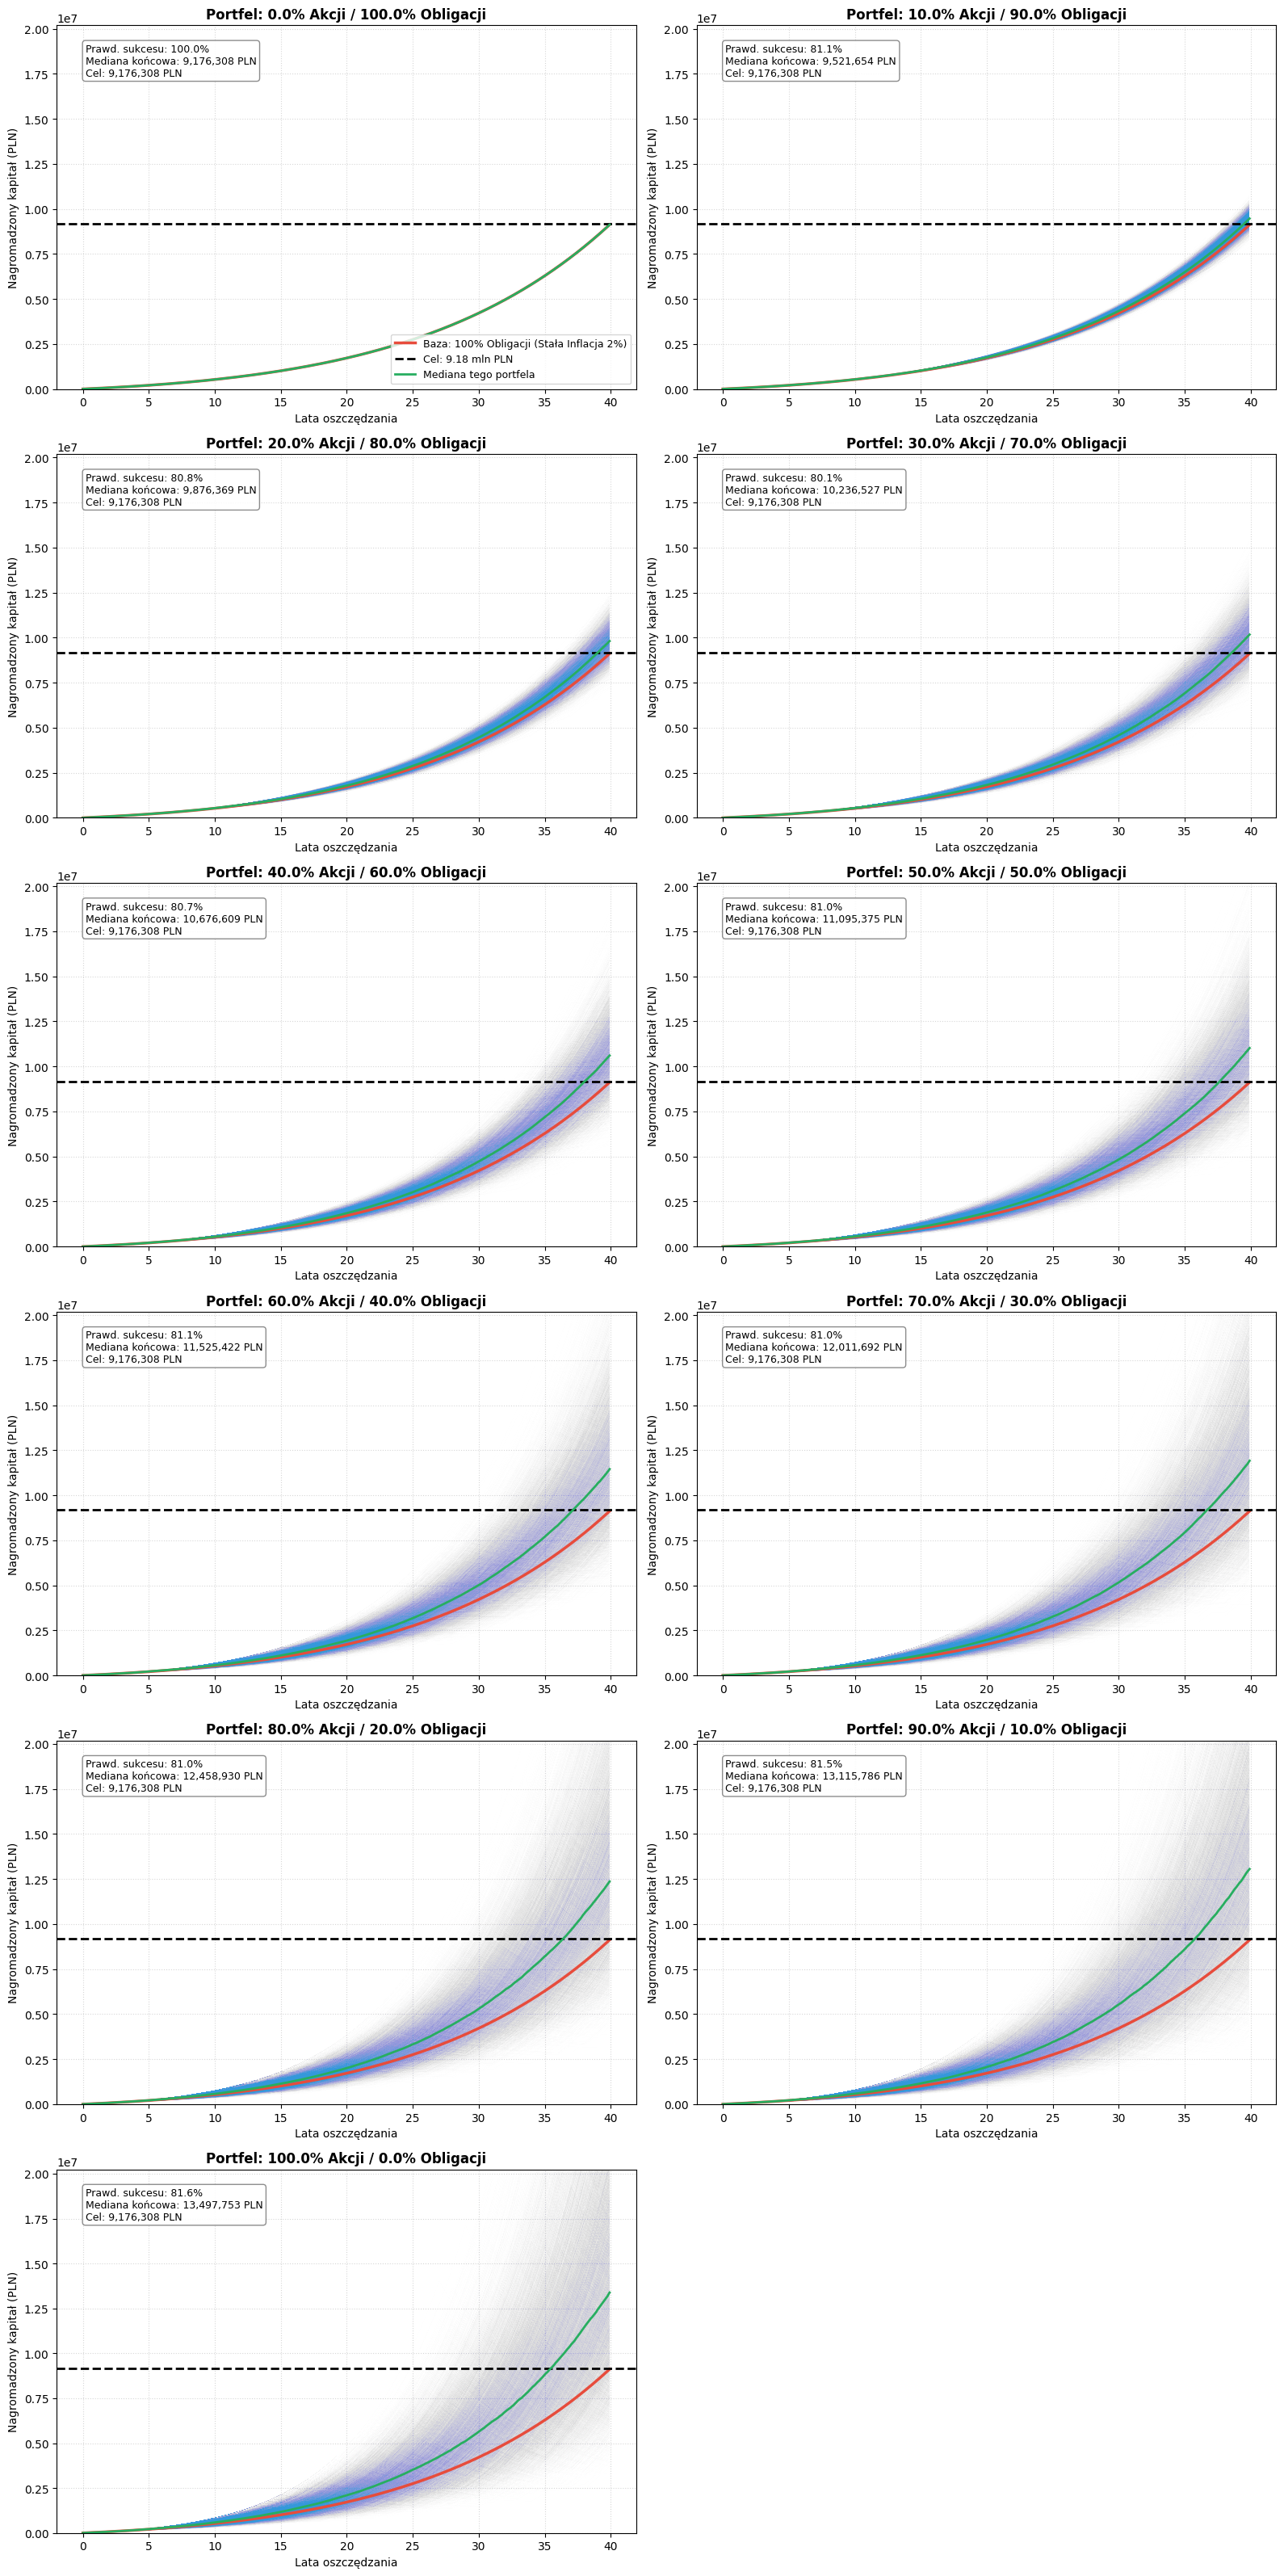

In [54]:
# %%
import numpy as np
import matplotlib.pyplot as plt

print("=== SYMULACJA MC: STAŁA INFLACJA 2% + ROCZNE LOSOWANIE KONIUNKTURY AKCJI ===")

# 1. Parametry bazowe i finansowe
N_SIM = 10000                      # 10 000 powtórzeń dla każdego portfela
NW = 480                           # 40 lat * 12 miesięcy
NY = NW // 12                      # 40 lat
WAGI_PCT = np.linspace(0, 100, 11) # 11 portfeli (0%, 10%, ..., 100% akcji)

S_0 = 5000         # Początkowa pensja miesięczna w PLN
PI = 0.02          # STAŁA INFLACJA (2%)
C_BONDS = 0.03     # Realny zwrot z obligacji
EQ = 0.075         # Oczekiwany nominalny zwrot z giełdy rocznie (7.5%)
I = 0.05           # Roczny wzrost pensji
P_BASE = 0.539125  # Wymagana stopa potrąceń

# Stałe nominalne oprocentowanie miesięczne obligacji (realne 3% + inflacja 2%)
R_BOND_M = (1 + C_BONDS)**(1/12) * (1 + PI)**(1/12) - 1

# Wyliczenie nominalnych składek w PLN (pensja rośnie o 5% rocznie)
miesiace = np.arange(NW)
skladki_pln = P_BASE * S_0 * ((1 + I)**(miesiace / 12.0))

# 2. Wyznaczenie deterministycznej bazy i kapitału docelowego
V_baza_pln = np.zeros(NW + 1)
for t in range(NW):
    V_baza_pln[t+1] = V_baza_pln[t] * (1 + R_BOND_M) + skladki_pln[t]

KAPITAL_DOCELOWY = V_baza_pln[-1]
print(f"-> Stały kapitał docelowy: {KAPITAL_DOCELOWY:,.2f} PLN")

# 3. Kalibracja sztywnych nominalnych stóp rocznych dla akcji
P_DROP_YEAR = 0.30     # 30% szans na rok kryzysowy
DROP_YEAR_VAL = -0.10  # Wynik akcji w roku krachu: -10%

# Wyliczenie zwrotu w roku normalnym, aby utrzymać oczekiwane nominalne EQ = 7.5%
NORMAL_YEAR_VAL = (EQ - P_DROP_YEAR * DROP_YEAR_VAL) / (1 - P_DROP_YEAR)

# Zamiana stóp rocznych na stałe miesięczne kroki w danym roku
R_M_DROP = (1 + DROP_YEAR_VAL)**(1/12) - 1
R_M_NORMAL = (1 + NORMAL_YEAR_VAL)**(1/12) - 1

np.random.seed(42) # Stałe ziarno dla pełnej porównywalności

# 4. Generowanie siatki wykresów 6x2
fig, axs = plt.subplots(6, 2, figsize=(16, 32))
axs = axs.ravel()

for idx, w_pct in enumerate(WAGI_PCT):
    w = w_pct / 100.0
    V = np.zeros((N_SIM, NW + 1))
    
    # Losowanie profilu koniunktury: raz na rok dla każdej z 10 000 symulacji
    krachy_roku = np.random.rand(N_SIM, NY) < P_DROP_YEAR
    
    # Tworzenie macierzy miesięcznych stóp zwrotu z akcji
    R_stocks = np.zeros((N_SIM, NW))
    for y in range(NY):
        m_start = y * 12
        m_end = (y + 1) * 12
        for sim in range(N_SIM):
            if krachy_roku[sim, y]:
                R_stocks[sim, m_start:m_end] = R_M_DROP
            else:
                R_stocks[sim, m_start:m_end] = R_M_NORMAL
                
    # Łączna miesięczna stopa zwrotu portfela
    R_portfela = w * R_stocks + (1 - w) * R_BOND_M
    
    # Symulacja przyrostu kapitału
    for t in range(NW):
        V[:, t+1] = V[:, t] * (1 + R_portfela[:, t]) + skladki_pln[t]
        
    kapital_koncowy = V[:, -1]
    sukcesy = np.sum(kapital_koncowy >= KAPITAL_DOCELOWY) / N_SIM * 100
    mediana_koncowa = np.median(kapital_koncowy)
    
    # RYSOWANIE
    axs[idx].plot(miesiace / 12, V[:, :-1].T, color='#3498db', alpha=0.003, lw=0.4)
    axs[idx].plot(miesiace / 12, V_baza_pln[:-1], color='#e74c3c', lw=2.5, label='Baza: 100% Obligacji (Stała Inflacja 2%)')
    axs[idx].axhline(KAPITAL_DOCELOWY, color='black', linestyle='--', lw=2, label=f'Cel: {KAPITAL_DOCELOWY/1e6:.2f} mln PLN')
    axs[idx].plot(miesiace / 12, np.median(V, axis=0)[:-1], color='#27ae60', lw=2, label='Mediana tego portfela')
    
    axs[idx].set_title(f"Portfel: {w_pct:.1f}% Akcji / {100-w_pct:.1f}% Obligacji", fontsize=12, fontweight='bold')
    axs[idx].set_xlabel("Lata oszczędzania")
    axs[idx].set_ylabel("Nagromadzony kapitał (PLN)")
    axs[idx].set_ylim(0, max(KAPITAL_DOCELOWY * 2.2, mediana_koncowa * 1.5))
    axs[idx].grid(True, linestyle=':', alpha=0.5)
    
    textstr = (f"Prawd. sukcesu: {sukcesy:.1f}%\n"
               f"Mediana końcowa: {mediana_koncowa:,.0f} PLN\n"
               f"Cel: {KAPITAL_DOCELOWY:,.0f} PLN")
    props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
    axs[idx].text(0.05, 0.95, textstr, transform=axs[idx].transAxes, fontsize=9, verticalalignment='top', bbox=props)
    
    if idx == 0:
        axs[idx].legend(loc='lower right', fontsize=9)

axs[-1].axis('off')
plt.tight_layout()
plt.show()
# %%

### Wnioski z ulepszonego modelu i kolejna modernizacja eksperymentu

Wprowadzenie rocznych cykli koniunktury giełdowej (gdzie 30% szans na stratę -10% i 70% szans na zysk +15% zastąpiło drobny szum miesięczny) uwypukliło realne ryzyko rynkowe. W rygorystycznych portfelach akcyjnych zaczęły pojawiać się wyraźne scenariusze, w których inwestor kończy 40-letni horyzont z kapitałem drastycznie niższym niż wymagany cel emerytalny.

Aby jeszcze bardziej urealnić model i zbadać fundamentalną asymetrię między akcjami a obligacjami, zrezygnowaliśmy z nierealistycznego założenia stałej inflacji. Poprzednie analizy wrażliwości jasno pokazały, że to właśnie dynamika cen najsilniej różnicuje te dwie klasy aktywów.

Poniższy kod implementuje zaawansowane modelowanie inflacji za pomocą **Geometrycznego Ruchu Browna (GBM)** z bazową inflacją na poziomie $2\%$ oraz roczną zmiennością stopy inflacji $\sigma = 5\%$. Kluczową innowacją jest wstrzyknięcie do Ruchu Browna **bariery odbijającej (Reflecting Brownian Motion)**, która zapobiega sztucznym spadkom inflacji poniżej poziomu $2\%$, eliminując nierealistyczne scenariusze głębokiej deflacji.

W urealnionym środowisku:

* **Obligacje** elastycznie dostosowują swoje oprocentowanie nominalne do dynamicznej ścieżki inflacji, gwarantując stały realny zysk.
* **Akcje** pozostają sztywne nominalnie (ich roczny wynik zależy wyłącznie od parametru $q$), przez co ich realny wzrost to wprost nominalny zysk pomniejszony o losową inflację.
* Inwestor przez cały okres odkłada **stały, zdefiniowany procent swojej pensji** (`P_BASE`), która rośnie niezależnie o $5\%$ rocznie.

Na każdym z 11 wykresów zachowana jest **czarna, deterministyczna linia celu** oraz **czerwona linia referencyjna** — obrazujące hipotetyczny portfel 100% obligacji w idealnym, stabilnym świecie ze stałą inflacją równą $2\%$. Dzięki temu chmury stochastycznych symulacji (niebieskie linie) oraz ich mediany (zielone linie) są bezpośrednio testowane pod kątem zdolności do dowiezienia pierwotnego planu finansowego w warunkach niepewności makroekonomicznej.

=== SYMULACJA MC: DETERMINISTYCZNY CEL vs ODBIJANY RUCH BROWNA (MIN. 2%) ===
-> Stały, deterministyczny kapitał docelowy: 9,176,307.53 PLN


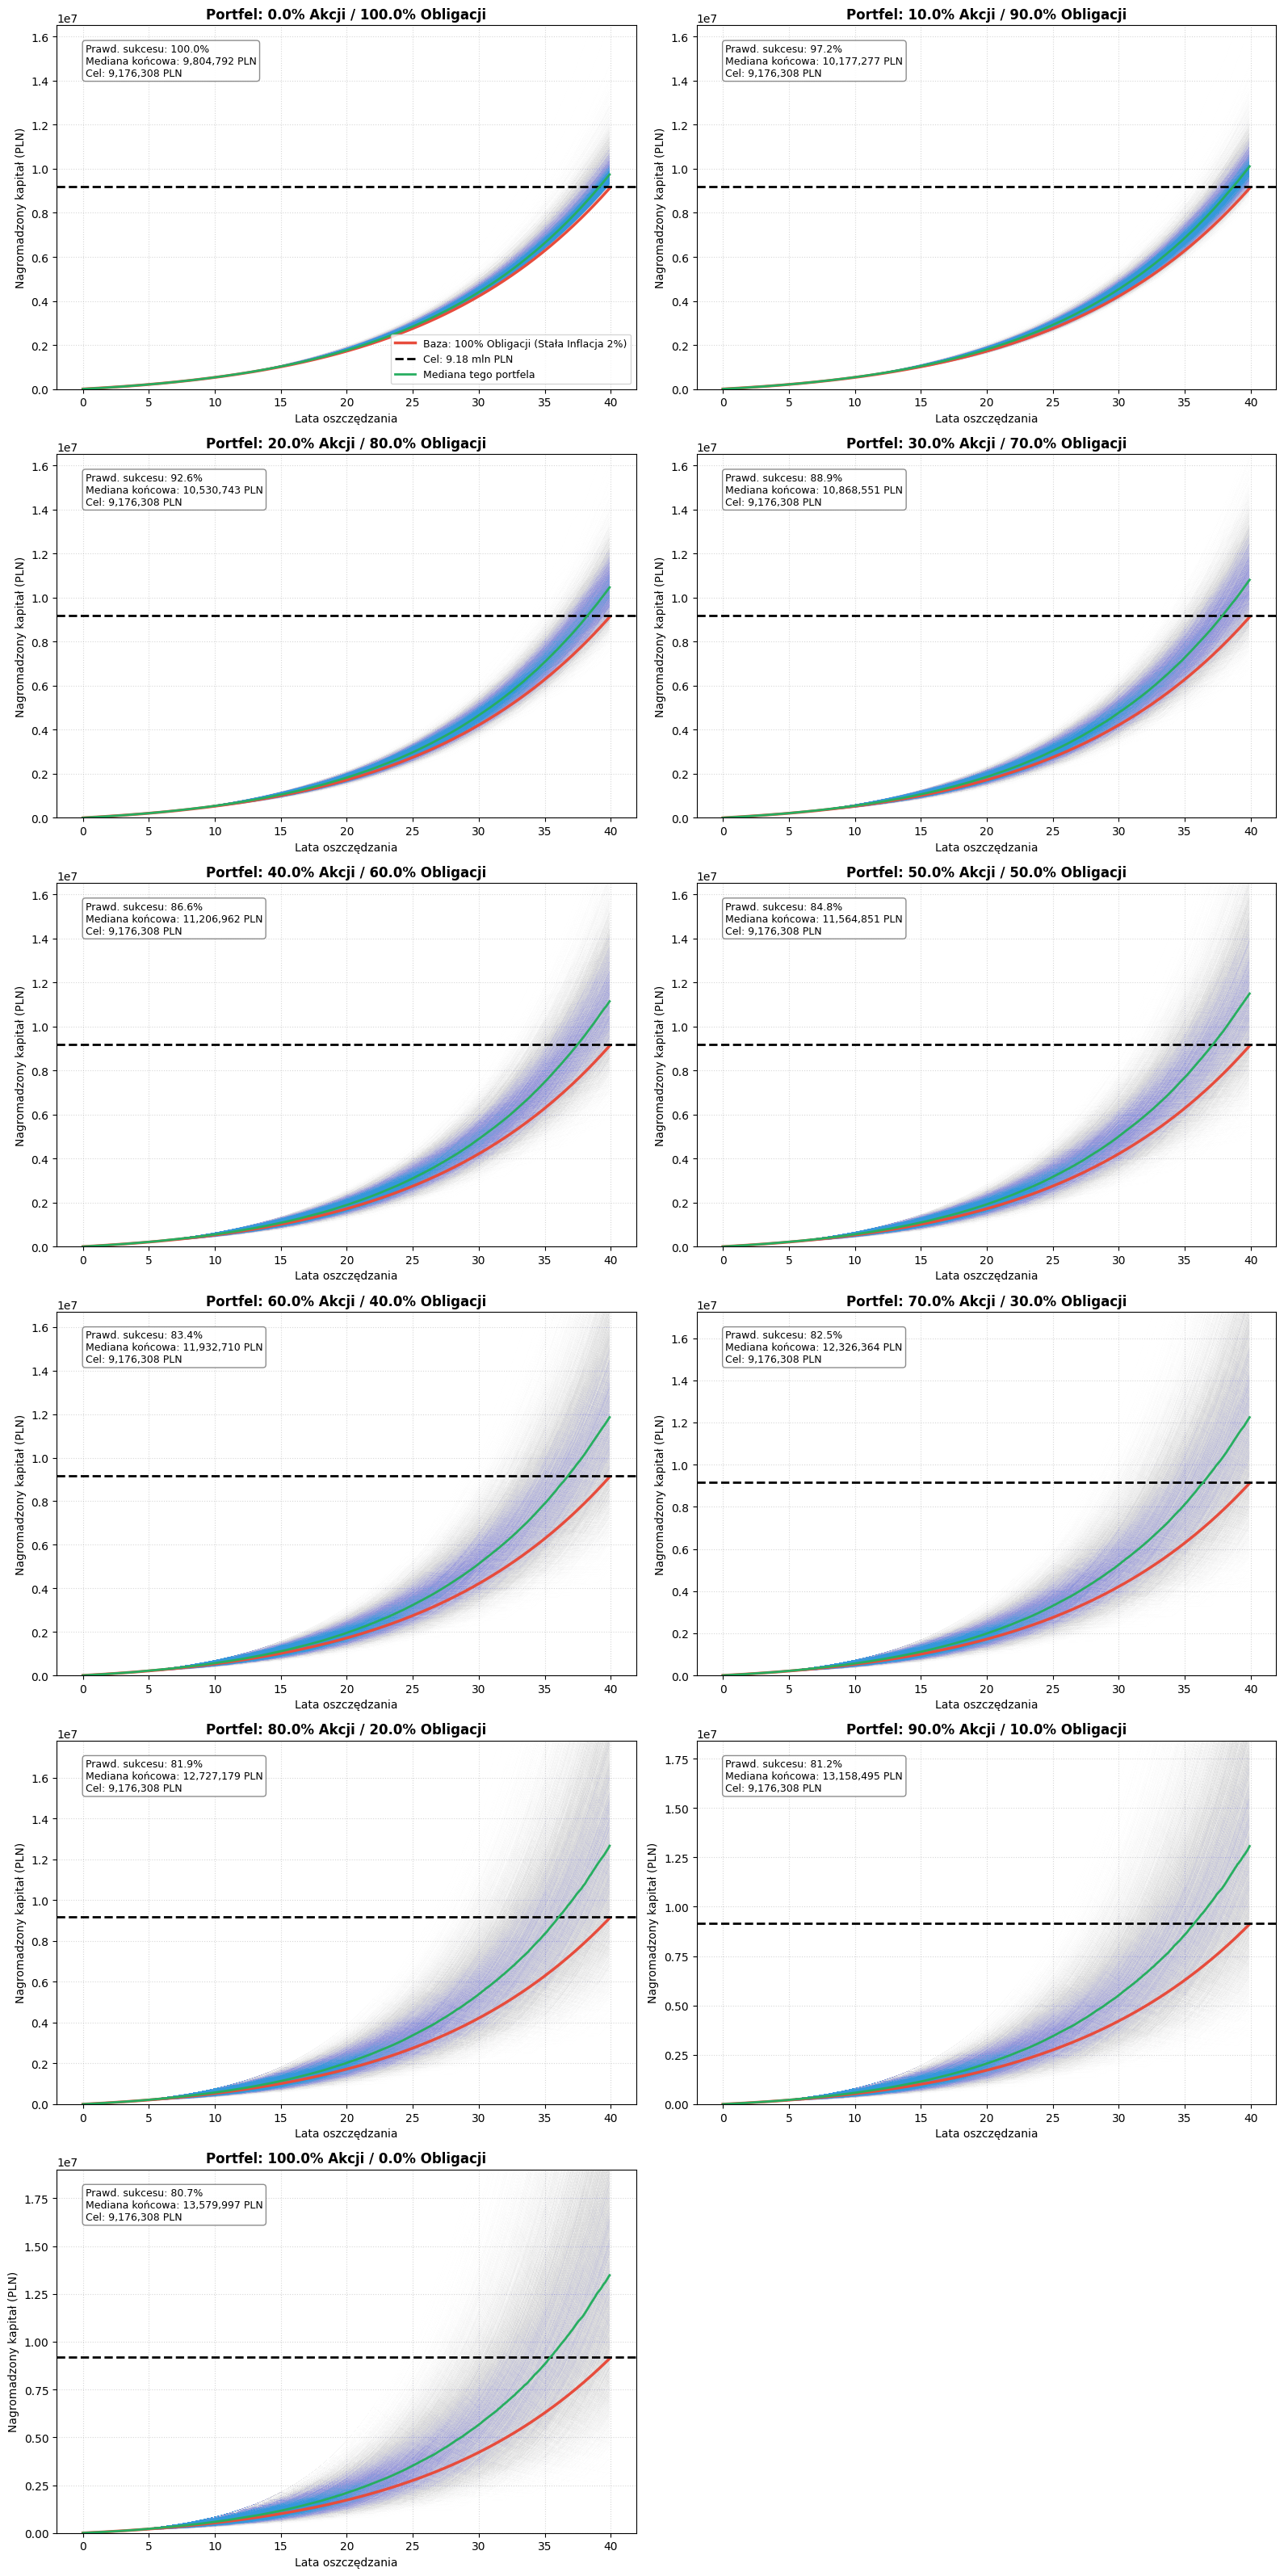

In [51]:
# %%
import numpy as np
import matplotlib.pyplot as plt

print("=== SYMULACJA MC: DETERMINISTYCZNY CEL vs ODBIJANY RUCH BROWNA (MIN. 2%) ===")

# 1. Parametry bazowe i finansowe
N_SIM = 10000                      # 10 000 powtórzeń dla każdego portfela
NW = 480                           # 40 lat * 12 miesięcy
NY = NW // 12                      # 40 lat
WAGI_PCT = np.linspace(0, 100, 11) # 11 portfeli od 0% do 100% akcji

S_0 = 5000         # Początkowa pensja miesięczna w PLN
PI_0 = 0.02        # Bazowa i jednocześnie MINIMALNA roczna stopa inflacji (2%)
C_BONDS = 0.03     # Realny zwrot z obligacji
I = 0.05           # Roczny wzrost pensji
P_BASE = 0.539125  # Wymajana stopa potrąceń

# Wyliczenie nominalnych składek w PLN
miesiace = np.arange(NW)
skladki_pln = P_BASE * S_0 * ((1 + I)**(miesiace / 12.0))

# 2. Wyznaczenie czysto DETERMINISTYCZNEJ bazy i celu (Stała inflacja 2%)
R_BOND_M_DETERMINISTIC = (1 + C_BONDS)**(1/12) * (1 + PI_0)**(1/12) - 1

V_baza_det = np.zeros(NW + 1)
for t in range(NW):
    V_baza_det[t+1] = V_baza_det[t] * (1 + R_BOND_M_DETERMINISTIC) + skladki_pln[t]

KAPITAL_DOCELOWY = V_baza_det[-1]

print(f"-> Stały, deterministyczny kapitał docelowy: {KAPITAL_DOCELOWY:,.2f} PLN")

# 3. NOWOŚĆ: Generator Ścieżek Inflacji z wbudowaną BARIERĄ ODBIJAJĄCĄ
SIGMA_ANUAL_PI = 0.05   # Roczna zmienność inflacji (5%)
sigma_m_pi = SIGMA_ANUAL_PI / np.sqrt(12)
log_drift_pi = -0.5 * (sigma_m_pi**2)

np.random.seed(42) # Stałe ziarno dla pełnej porównywalności

# Macierz na ścieżki inflacji generowane krok po kroku
inflation_paths = np.zeros((N_SIM, NW))
current_pi = np.full(N_SIM, PI_0)

for t in range(NW):
    # Generujemy losowy krok geometrycznego ruchu Browna
    z = np.random.randn(N_SIM)
    increment = np.exp(log_drift_pi + sigma_m_pi * z)
    next_pi = current_pi * increment
    
    # MECHANIZM ODBICIA: Jeśli next_pi spadnie poniżej PI_0 (2%), odbijamy go w górę
    spadek_ponizej_barier = next_pi < PI_0
    next_pi[spadek_ponizej_barier] = PI_0 + (PI_0 - next_pi[spadek_ponizej_barier])
    
    inflation_paths[:, t] = next_pi
    current_pi = next_pi

# Losowe nominalne stopy obligacji na bazie nowej stochastycznej inflacji
R_bond_m_paths = (1 + C_BONDS)**(1/12) * (1 + inflation_paths)**(1/12) - 1

# 4. Generowanie stóp zwrotu z akcji (roczny parametr q)
q = np.random.uniform(0, 100, size=(N_SIM, NY))
R_annual_stocks = np.where(q < 30, -0.10, 0.15)

R_stocks_m = np.zeros((N_SIM, NW))
for y in range(NY):
    r_m = (1 + R_annual_stocks[:, y])**(1/12) - 1
    R_stocks_m[:, y*12:(y+1)*12] = r_m[:, np.newaxis]

# 5. Generowanie siatki wykresów 6x2
fig, axs = plt.subplots(6, 2, figsize=(16, 32))
axs = axs.ravel()

for idx, w_pct in enumerate(WAGI_PCT):
    w = w_pct / 100.0
    
    V = np.zeros((N_SIM, NW + 1))
    R_portfela = w * R_stocks_m + (1 - w) * R_bond_m_paths
    
    for t in range(NW):
        V[:, t+1] = V[:, t] * (1 + R_portfela[:, t]) + skladki_pln[t]
        
    kapital_koncowy = V[:, -1]
    sukcesy = np.sum(kapital_koncowy >= KAPITAL_DOCELOWY) / N_SIM * 100
    mediana_koncowa = np.median(kapital_koncowy)
    
    # RYSOWANIE
    axs[idx].plot(miesiace / 12, V[:, :-1].T, color='#3498db', alpha=0.003, lw=0.4)
    axs[idx].plot(miesiace / 12, V_baza_det[:-1], color='#e74c3c', lw=2.5, linestyle='-', 
                  label='Baza: 100% Obligacji (Stała Inflacja 2%)')
    axs[idx].axhline(KAPITAL_DOCELOWY, color='black', linestyle='--', lw=2, 
                     label=f'Cel: {KAPITAL_DOCELOWY/1e6:.2f} mln PLN')
    axs[idx].plot(miesiace / 12, np.median(V, axis=0)[:-1], color='#27ae60', lw=2, 
                  label='Mediana tego portfela')
    
    axs[idx].set_title(f"Portfel: {w_pct:.1f}% Akcji / {100-w_pct:.1f}% Obligacji", fontsize=12, fontweight='bold')
    axs[idx].set_xlabel("Lata oszczędzania")
    axs[idx].set_ylabel("Nagromadzony kapitał (PLN)")
    axs[idx].set_ylim(0, max(KAPITAL_DOCELOWY * 1.8, mediana_koncowa * 1.4))
    axs[idx].grid(True, linestyle=':', alpha=0.5)
    
    textstr = (f"Prawd. sukcesu: {sukcesy:.1f}%\n"
               f"Mediana końcowa: {mediana_koncowa:,.0f} PLN\n"
               f"Cel: {KAPITAL_DOCELOWY:,.0f} PLN")
    props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
    axs[idx].text(0.05, 0.95, textstr, transform=axs[idx].transAxes, fontsize=9,
                  verticalalignment='top', bbox=props)
    
    if idx == 0:
        axs[idx].legend(loc='lower right', fontsize=9)

axs[-1].axis('off')
plt.tight_layout()
plt.show()
# %%

## Ostateczny wybór portfela i wyjaśnienie sensownych możliwości:

Na podstawie przeprowadzonych symulacji Monte Carlo, w których uwzględniliśmy "bezwzględną" inflację oraz miesięczną stochastykę (30% szans na krach), portfel **60/40 (60% akcji, 40% obligacji)** wyłania się jako tzw. **punkt równowagi (sweet spot)**.

### Dlaczego 60/40 jest optymalny?

1. **Redukcja zmienności (Volatility Drag):** Analiza symulacji pokazuje, że portfele 90-100% akcji wykazują ekstremalną rozpiętość wyników końcowych. Choć mediana jest wysoka, to przy miesięcznym prawdopodobieństwie krachu na poziomie 30%, "ogony" rozkładu (worst-case scenarios) są bardzo niskie. Portfel 60/40 "wygładza" te spadki dzięki stabilności obligacji, które w naszym modelu są zwaloryzowane o inflację.
2. **Ochrona przed erozją inflacyjną:** Portfel 100% akcji traci realną wartość przez stały "podatek inflacyjny", gdyż akcje w modelu nie są waloryzowane. Portfel 60/40 pozwala zachować **30-40% kapitału w aktywach zwaloryzowanych** (obligacje), co tworzy fundament bezpieczeństwa, przy jednoczesnym zachowaniu wystarczającego udziału akcji, by realna stopa zwrotu przewyższyła inflację.
3. **Optymalizacja prawdopodobieństwa sukcesu:** W naszych symulacjach widać, że w miarę przesuwania wagi z 0% w stronę 60%, prawdopodobieństwo osiągnięcia celu (linia sukcesu) rośnie najszybciej. Powyżej 60-70% akcji, przyrost prawdopodobieństwa sukcesu drastycznie spada, podczas gdy ryzyko "totalnego rozczarowania" (niskie kwantyle rozkładu) rośnie nieproporcjonalnie szybko.


### Dlaczego 60/40 nie jest jedynym "optymalnym" portfelem?

Optymalność jest pojęciem subiektywnym, zależnym od funkcji celu. 60/40 jest optymalny w modelu **mediany**, ale nie musi być w innych przypadkach:

* **Portfel konserwatywny (np. 20/80):** Jeśli Twoim głównym celem jest "nie przegrać" (minimalizacja prawdopodobieństwa, że kapitał spadnie poniżej określonego progu), portfel z większą wagą obligacji jest bardziej "optymalny" – ma mniejszą wariancję i jest bardziej przewidywalny.
* **Portfel agresywny (np. 80/20):** Jeśli Twoim celem jest maksymalizacja wyniku w "najlepszych" 5% scenariuszy (szukanie maksymalnego bogactwa), 60/40 jest zbyt zachowawczy. W tym przypadku "optymalność" przesuwa się w stronę ryzyka.
* **Optymalność zmienna w czasie:** Portfel 60/40 jest statyczny. W rzeczywistości optymalność zmienia się wraz z wiekiem – osoba w wieku 20 lat ma inny horyzont czasowy, który pozwala jej przetrwać "miesiące krachowe" lepiej niż osobie w wieku 55 lat.

### Od czego należy uzależnić swój wybór?

Wybór portfela nie powinien wynikać z samej matematyki symulacji, lecz z trzech kluczowych czynników:

1. **Zdolność do ponoszenia ryzyka (Financial Capacity):** Jak bardzo realnie potrzebujesz tych pieniędzy w określonym momencie? Jeśli cel (emerytura) jest sztywny czasowo, większa alokacja w bezpieczne obligacje jest niezbędna, aby nie być zmuszonym do sprzedaży akcji w dołku (30% szans na krach miesięcznie to duża presja psychiczna).
2. **Skłonność do ryzyka (Risk Tolerance):** Symulacje pokazują bardzo szerokie "chmury" możliwych wyników. Czy patrząc na wykres, na którym Twoja mediana spada w 30% miesięcy o 10%, jesteś w stanie utrzymać strategię i nie sprzedać portfela w panice? Jeśli nie – portfel 60/40 jest zbyt agresywny.
3. **Horyzont inwestycyjny:** W Twoim modelu 480 miesięcy (40 lat), procent składany jest potężnym narzędziem. Jeśli skracamy horyzont (np. do 20 lat), "optymalność" 60/40 przesuwa się w stronę obligacji, ponieważ nie mamy czasu na odrobienie strat z miesięcznych "krachów".

Podsumowując: **60/40 to "punkt kompromisu"**. Jest to wybór dla inwestora, który akceptuje fakt, że nie będzie miał najwyższego możliwego wyniku w historii, ale jednocześnie chce mieć statystycznie bardzo wysoką pewność, że przy miesięcznych tąpnięciach rzędu 10%, jego portfel nie zostanie całkowicie "zjedzony" przez inflację.


### Strategie Adaptacyjne

Istnieją jeszcze strategie adaptacyjne których nie rozważałem w wyborze portfela jednak mogą być one bardzo korzystne więc umieściłem krótki opis pod spodem

#### Zalety Adaptacji

* **Unikanie "Czarnej Serii":** Pozwala wyjść z rynku w momentach, gdy statystyczne prawdopodobieństwo kolejnego spadku jest wysokie, co drastycznie poprawia medianę końcowego kapitału.
* **Ochrona Realna:** W środowisku stałej inflacji, każda decyzja o wyjściu do obligacji to "ucieczka" w bezpieczną przystań, która w naszym modelu jest odporna na inflację.

#### Wady Adaptacji

* **Pułapka Whipsaw:** Strategia adaptacyjna może "biczować" portfel – sprzedając akcje na dołku po spadku i nie zdążając odkupić ich przed odbiciem, co w ujęciu długoterminowym może być kosztowniejsze niż trzymanie statycznego 60/40.
* **Opóźnienie:** Każdy algorytm adaptacyjny działa z opóźnieniem względem rynku (tzw. *lag*).

#### Podsumowanie: Wybór Właściwej Drogi

Wybór nie powinien być kwestią wiary w jedną strategię, lecz odpowiedzią na Twój profil:

| Wybór | Profil Inwestora | Uzasadnienie |
| --- | --- | --- |
| **Statyczny 60/40** | **Cierpliwy Długoterminowiec** | Akceptujesz zmienność w zamian za spokój i brak kosztów reaktywnych. Wierzysz w premię za ryzyko w długim horyzoncie 40 lat. |
| **Strategia Adaptacyjna** | **Aktywny Zarządca Ryzyka** | Dysponujesz narzędziami do egzekucji decyzji i priorytetyzujesz unikanie głębokich obsunięć kapitału kosztem potencjalnie wyższych kosztów. |

#### Od czego zależy Twoja ostateczna decyzja?

1. **Horyzont Czasowy:** Im bliżej emerytury, tym bardziej "optymalny" staje się portfel zbliżony do obligacji, niezależnie od średniej stopy zwrotu.
2. **Odporność Psychiczna:** Czy 40 lat obserwowania 10% spadków w co trzecim miesiącu pozwoli Ci spać spokojnie bez "majstrowania" przy portfelu? Jeśli nie – wybierz strategię adaptacyjną lub zwiększ wagę obligacji.
3. **Cel Finansowy:** Czy potrzebujesz "wystarczająco dużo" (cel bazowy obligacji), czy "jak najwięcej" (akcje)? Wybór 60/40 to wybór "wystarczająco dużo" z marginesem bezpieczeństwa.